<div style="background:linear-gradient(110deg,#12132E 0%,#3730A3 45%,#0D9488 100%);border-radius:16px;padding:34px 34px;text-align:center"><div style="color:#C7D2FE;font-size:15px;font-weight:700;letter-spacing:3px">DEEP LEARNING · SEQUENCE MODELS</div><div style="color:#FFFFFF;font-size:42px;font-weight:800;margin-top:8px">Lab — RNN, LSTM, GRU &amp; Attention</div><div style="color:#E0E7FF;font-size:18px;font-style:italic;margin-top:10px">Build, train and compare recurrent models on three data modalities — and learn to <b>prepare sequential data</b> the right way</div><div style="margin-top:16px"><span style="background:#4F46E5;color:#fff;border-radius:20px;padding:6px 16px;font-weight:700;margin:0 4px">RNN</span><span style="background:#0D9488;color:#fff;border-radius:20px;padding:6px 16px;font-weight:700;margin:0 4px">LSTM</span><span style="background:#7C3AED;color:#fff;border-radius:20px;padding:6px 16px;font-weight:700;margin:0 4px">GRU</span><span style="background:#E11D48;color:#fff;border-radius:20px;padding:6px 16px;font-weight:700;margin:0 4px">Attention</span></div></div>

### How this lab works

| Part | Models & technique | Data modality | Dataset |
|------|--------------------|---------------|---------|
| **1** | SimpleRNN · LSTM · GRU + `return_sequences` | ⏱️ **temporal** | stock prices (`data.csv`) |
| **2** | GRU · GRU + Attention | 📝 **text** | poems (`poems.txt`) |
| **3** | RNN · RNN + Attention | 🎯 attention focus | synthetic "pointer" task |
| **4** | LSTM (generative) | 🎵 **audio** | Irish tunes (`songs.json`) |
| **5** | — | synthesis | comparison & guidance |

Every part begins with a **🧱 Data-preparation** section with an **illustration**, because *how you shape sequential data is half the battle*. Look for the colored boxes:

<div style="background:#EEF2FF;border:1px solid #4F46E555;border-left:5px solid #4F46E5;border-radius:10px;padding:12px 16px;margin:10px 0"><div style="color:#4F46E5;font-weight:700;font-size:15px;margin-bottom:4px">🧱 Data preparation</div><div style="color:#1f2937;font-size:15px;line-height:1.5">how to turn raw data into model-ready tensors</div></div><div style="background:#ECFEFF;border:1px solid #0D948855;border-left:5px solid #0D9488;border-radius:10px;padding:12px 16px;margin:10px 0"><div style="color:#0D9488;font-weight:700;font-size:15px;margin-bottom:4px">💡 Tip</div><div style="color:#1f2937;font-size:15px;line-height:1.5">a practical best-practice</div></div><div style="background:#FFF7ED;border:1px solid #F59E0B55;border-left:5px solid #F59E0B;border-radius:10px;padding:12px 16px;margin:10px 0"><div style="color:#F59E0B;font-weight:700;font-size:15px;margin-bottom:4px">❓ Question</div><div style="color:#1f2937;font-size:15px;line-height:1.5">a question to answer (more of these than before — to draw your own conclusions)</div></div><div style="background:#FDF2F8;border:1px solid #E11D4855;border-left:5px solid #E11D48;border-radius:10px;padding:12px 16px;margin:10px 0"><div style="color:#E11D48;font-weight:700;font-size:15px;margin-bottom:4px">🔑 Key idea</div><div style="color:#1f2937;font-size:15px;line-height:1.5">the main lesson</div></div>

<div style="background:linear-gradient(100deg,#334155 0%,#12132E 100%);border-radius:14px;padding:20px 26px;margin:6px 0 2px 0"><div style="color:#FFFFFFcc;font-size:14px;font-weight:700;letter-spacing:2px">PART 0</div><div style="color:#FFFFFF;font-size:30px;font-weight:800;line-height:1.15;margin-top:2px">Setup</div><div style="color:#FFFFFFcc;font-size:16px;font-style:italic;margin-top:6px">imports, reproducibility, and a reusable live-loss plotter</div></div>

<div style="background:#ECFEFF;border:1px solid #0D948855;border-left:5px solid #0D9488;border-radius:10px;padding:12px 16px;margin:10px 0"><div style="color:#0D9488;font-weight:700;font-size:15px;margin-bottom:4px">💡 Tip</div><div style="color:#1f2937;font-size:15px;line-height:1.5">On Google Colab, upload <code>data.csv</code>, <code>poems.txt</code>, <code>songs.json</code> and <code>util.py</code>. The audio part also needs <code>regex</code> and the system tools <code>abcmidi</code> / <code>timidity</code>.</div></div>

In [ ]:
# On Colab, uncomment to upload the files:
# from google.colab import files
# files.upload()

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from IPython import display as ipythondisplay     # used by the music playback later
print("TensorFlow", tf.__version__)
np.random.seed(7); tf.random.set_seed(7)

<div style="border-left:5px solid #F59E0B;padding:6px 0 6px 12px;margin:14px 0 4px 0"><span style="color:#12132E;font-size:21px;font-weight:700">A reusable callback to watch the loss live</span></div>We will reuse this small Keras **callback** in several parts. It redraws the training &amp; validation loss curve at the end of every epoch, so you literally *watch the model learn*.

In [ ]:
class LivePlotLoss(tf.keras.callbacks.Callback):
    """Redraws train/val loss after each epoch (great for teaching)."""
    def __init__(self, title="Training"):
        self.title = title; self.tr = []; self.va = []
    def on_epoch_end(self, epoch, logs=None):
        logs = logs or {}
        self.tr.append(logs.get("loss"))
        if "val_loss" in logs: self.va.append(logs["val_loss"])
        ipythondisplay.clear_output(wait=True)
        plt.figure(figsize=(7, 4))
        plt.plot(self.tr, label="train loss", color="#4F46E5", lw=2)
        if self.va: plt.plot(self.va, label="val loss", color="#E11D48", lw=2)
        plt.title(f"{self.title} — epoch {epoch+1}")
        plt.xlabel("epoch"); plt.ylabel("loss"); plt.legend(); plt.grid(alpha=.3)
        plt.show()

# Usage:  model.fit(..., callbacks=[LivePlotLoss("my model")])

<div style="background:#ECFEFF;border:1px solid #0D948855;border-left:5px solid #0D9488;border-radius:10px;padding:12px 16px;margin:10px 0"><div style="color:#0D9488;font-weight:700;font-size:15px;margin-bottom:4px">💡 Tip</div><div style="color:#1f2937;font-size:15px;line-height:1.5">Add <code>callbacks=[LivePlotLoss("...")]</code> to any <code>model.fit(...)</code> call to see the curve update in real time. Below is what such a curve looks like once training finishes:</div></div>

<div align="center">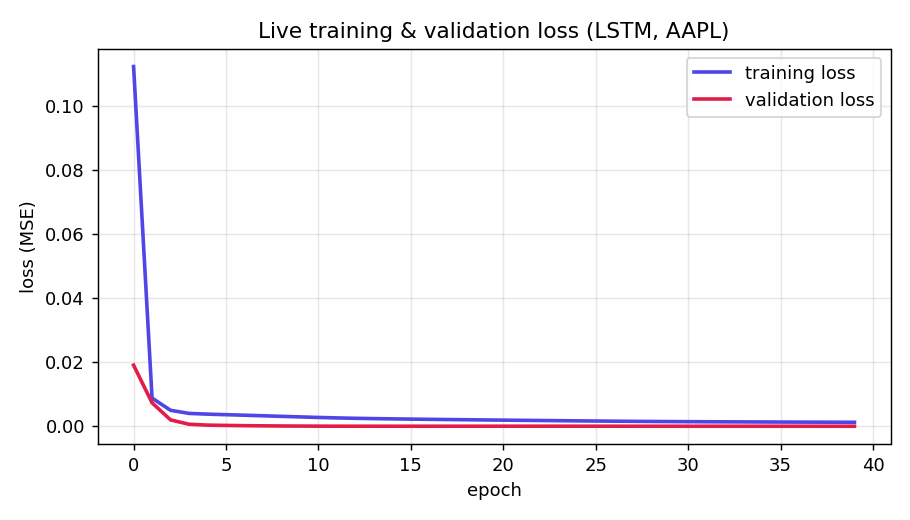<div style="color:#64748B;font-size:13px;font-style:italic;margin-top:6px">Training (blue) vs validation (red) loss — the gap tells you about over/under-fitting.</div></div>

<div style="background:linear-gradient(100deg,#4F46E5 0%,#12132E 100%);border-radius:14px;padding:20px 26px;margin:6px 0 2px 0"><div style="color:#FFFFFFcc;font-size:14px;font-weight:700;letter-spacing:2px">PART 1</div><div style="color:#FFFFFF;font-size:30px;font-weight:800;line-height:1.15;margin-top:2px">SimpleRNN vs LSTM vs GRU on a time series</div><div style="color:#FFFFFFcc;font-size:16px;font-style:italic;margin-top:6px">⏱️ temporal data — forecast tomorrow's price from the last few days</div></div>

Same data, same training — we only swap the recurrent cell. This is the fairest way to compare the three.

<div align="center">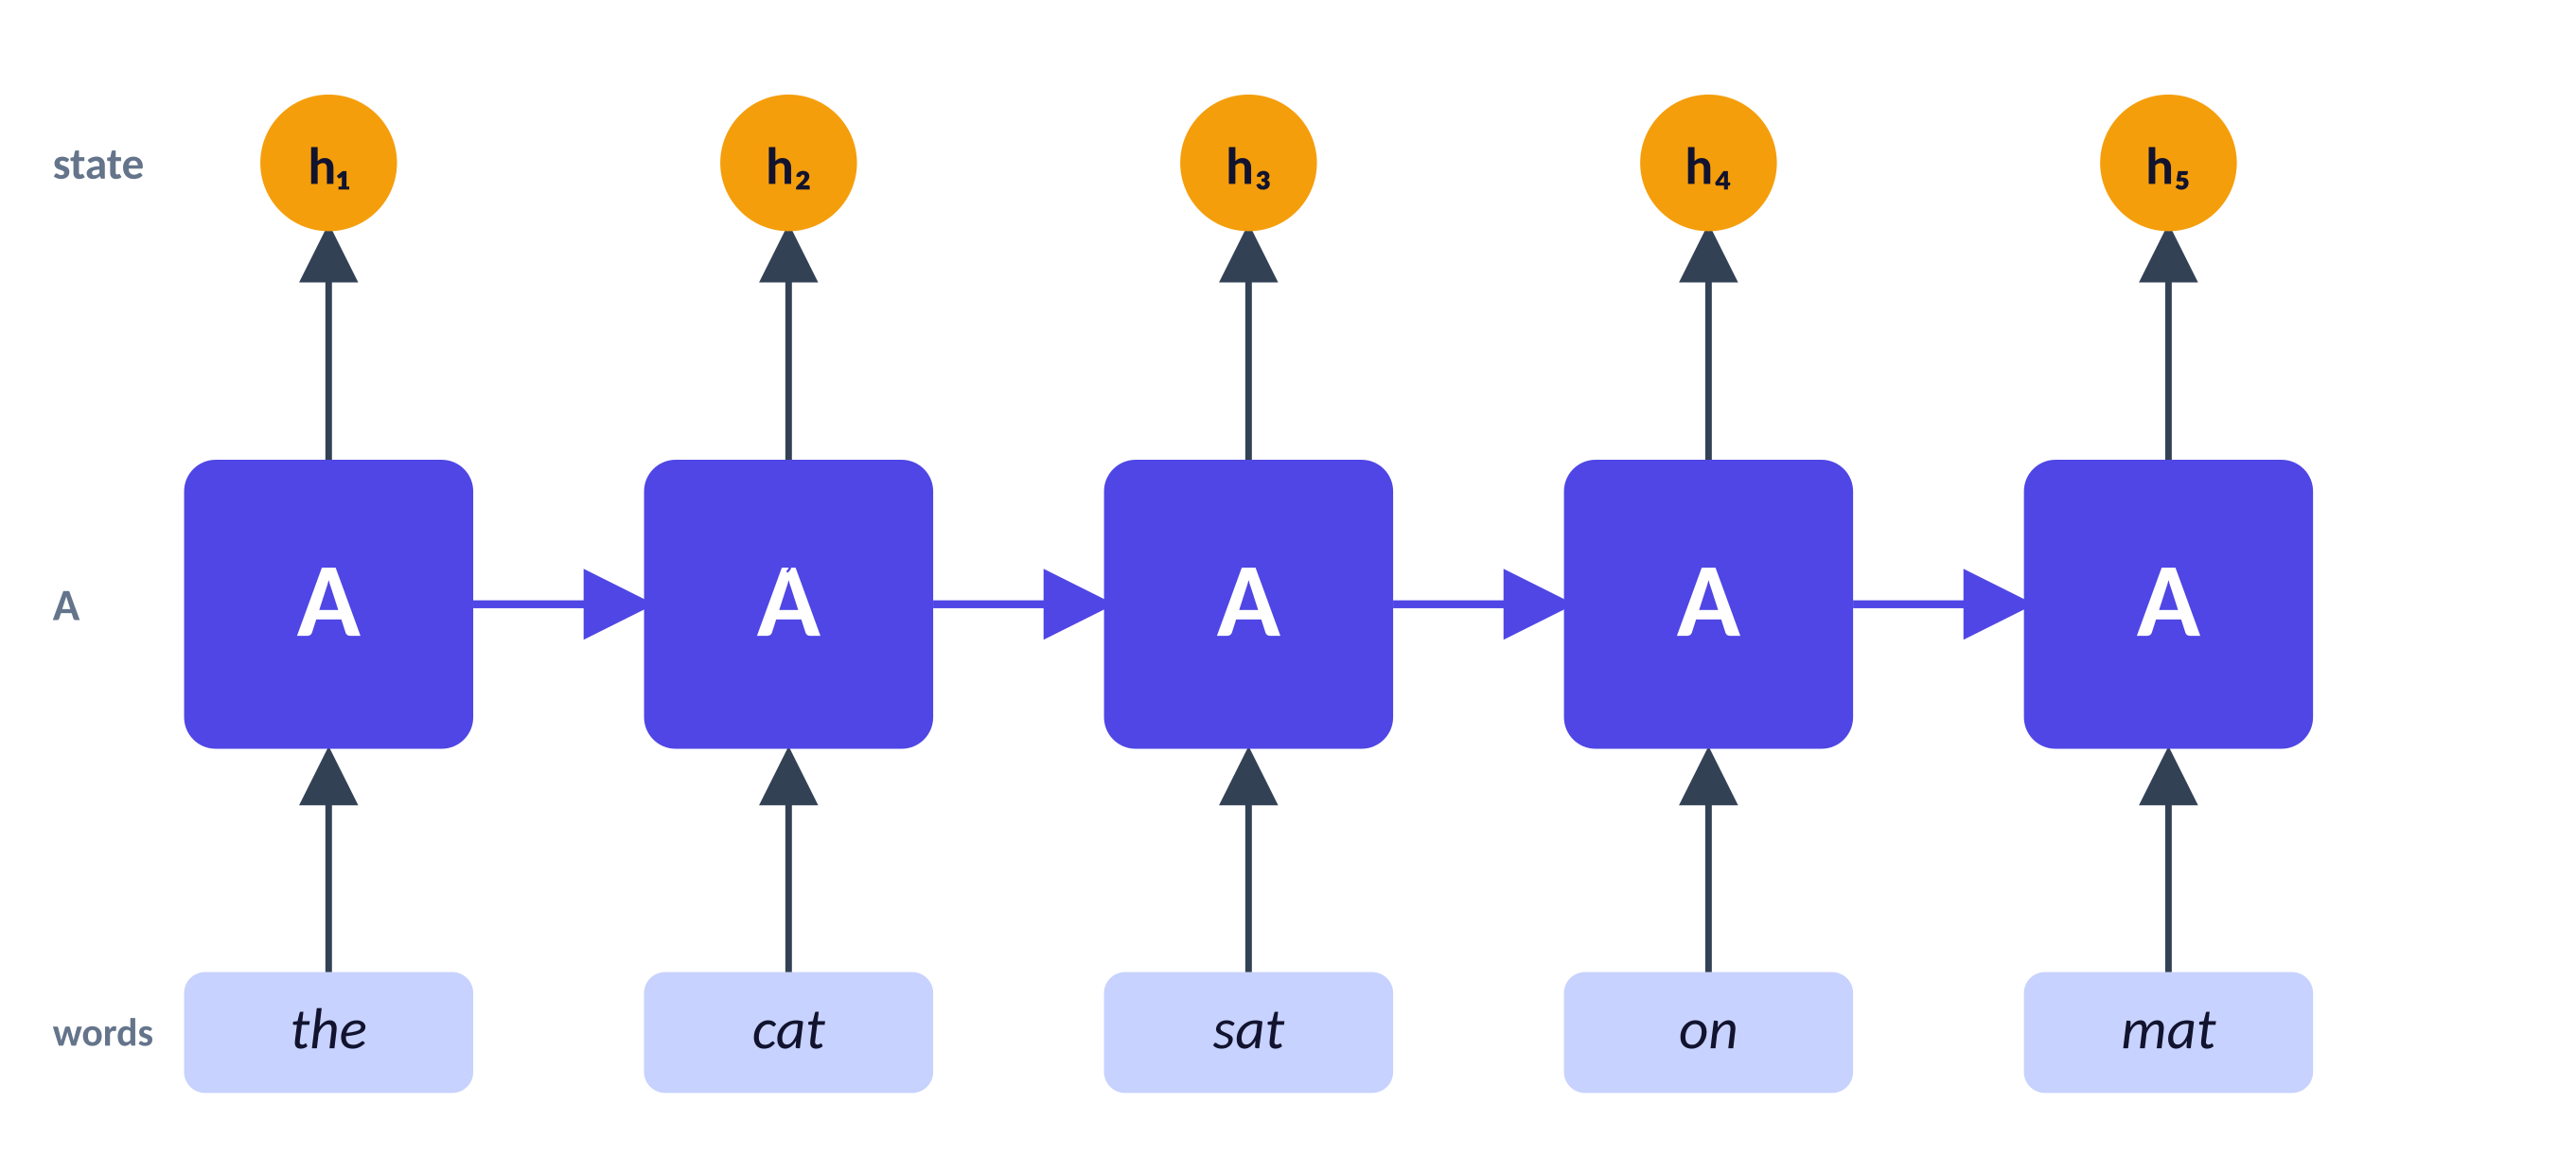<div style="color:#64748B;font-size:13px;font-style:italic;margin-top:6px">A recurrent cell unrolled through time (the same weights are reused at every step).</div></div>

<div style="border-left:5px solid #4F46E5;padding:6px 0 6px 12px;margin:14px 0 4px 0"><span style="color:#12132E;font-size:21px;font-weight:700">1.1 — 🧱 Preparing a time series for an RNN</span></div>

<div style="background:#EEF2FF;border:1px solid #4F46E555;border-left:5px solid #4F46E5;border-radius:10px;padding:12px 16px;margin:10px 0"><div style="color:#4F46E5;font-weight:700;font-size:15px;margin-bottom:4px">🧱 Data preparation</div><div style="color:#1f2937;font-size:15px;line-height:1.5">A raw price series is <b>one long vector</b>. An RNN needs many <b>(X, y) examples</b>. We build them with a <b>sliding window</b>: take <code>look_back</code> consecutive days as input <code>X</code>, and the very next day as the target <code>y</code>. Then slide one step and repeat. Two musts:<ul><li><b>Scale</b> the values to [0,1] using <b>training statistics only</b> (never peek at the test set → no leakage).</li><li>Reshape <code>X</code> to a <b>3-D tensor</b> <code>(samples, time-steps, features)</code> — what Keras RNNs expect.</li></ul></div></div>

<div align="center">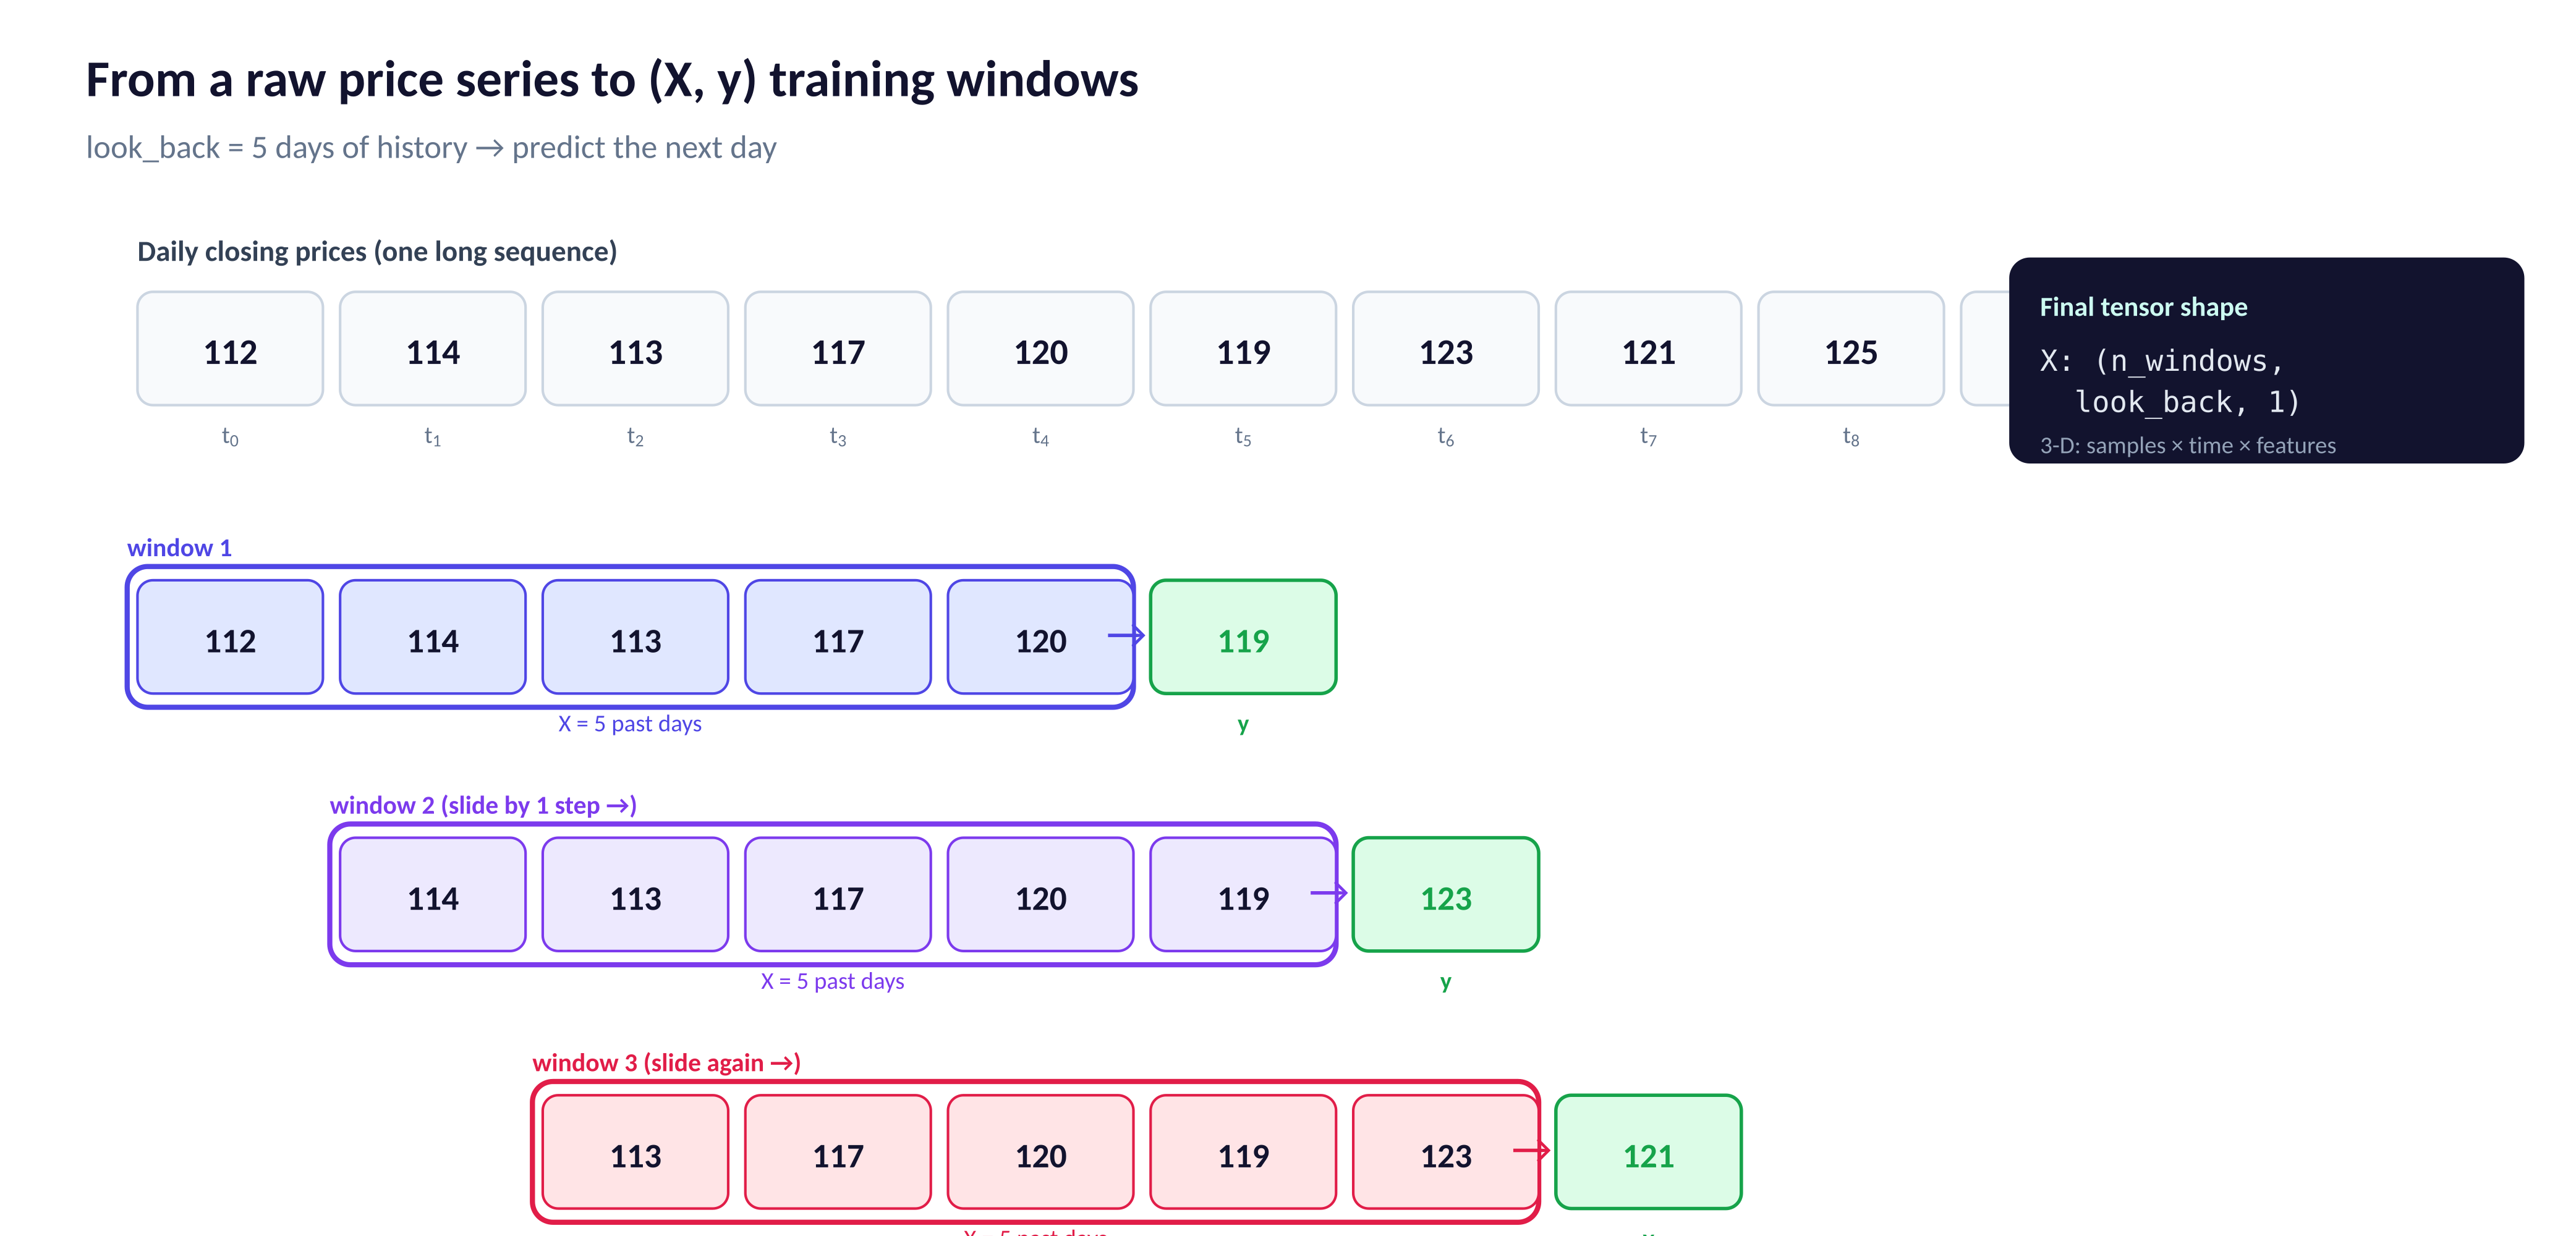<div style="color:#64748B;font-size:13px;font-style:italic;margin-top:6px">Sliding window: each colored box is one training example; slide by one step to get the next.</div></div>

<div style="border-left:5px solid #4F46E5;padding:6px 0 6px 12px;margin:14px 0 4px 0"><span style="color:#12132E;font-size:21px;font-weight:700">1.2 — Load and visualize the data</span></div>

In [ ]:
df = pd.read_csv('data.csv')
print("symbols:", df['symbol'].nunique(), "| rows:", len(df))

series = df[df['symbol'] == 'AAPL']['close'].values.astype('float32').reshape(-1, 1)
print("AAPL length:", len(series))

plt.figure(figsize=(9, 3))
plt.plot(series, color='#111827')
plt.title('AAPL daily close price'); plt.xlabel('day'); plt.ylabel('$'); plt.show()

<div style="border-left:5px solid #4F46E5;padding:6px 0 6px 12px;margin:14px 0 4px 0"><span style="color:#12132E;font-size:21px;font-weight:700">1.3 — Scale and build the sliding windows</span></div>

In [ ]:
n = len(series)
train_size = int(n * 0.8)

# normalize with TRAIN min/max only (no leakage)
mn, mx = series[:train_size].min(), series[:train_size].max()
scaled = (series - mn) / (mx - mn)
inv = lambda x: x * (mx - mn) + mn   # back to dollars

def make_windows(arr, look_back):
    X, y = [], []
    for i in range(len(arr) - look_back):
        X.append(arr[i:i+look_back, 0]); y.append(arr[i+look_back, 0])
    X = np.array(X); y = np.array(y)
    return X.reshape(X.shape[0], X.shape[1], 1), y   # 3-D: (samples, time, features)

look_back = 20
trainX, trainY = make_windows(scaled[:train_size], look_back)
testX,  testY  = make_windows(scaled[train_size:], look_back)
print("trainX", trainX.shape, "| testX", testX.shape)   # note the 3-D shape!

<div style="background:#FFF7ED;border:1px solid #F59E0B55;border-left:5px solid #F59E0B;border-radius:10px;padding:12px 16px;margin:10px 0"><div style="color:#F59E0B;font-weight:700;font-size:15px;margin-bottom:4px">❓ Question</div><div style="color:#1f2937;font-size:15px;line-height:1.5"><b>Q1.1</b> — Print <code>trainX.shape</code>. What does each of the three numbers mean? Why must the input be 3-D for a Keras RNN?<br><br><i>Your answer:</i> ...</div></div>

<div style="border-left:5px solid #4F46E5;padding:6px 0 6px 12px;margin:14px 0 4px 0"><span style="color:#12132E;font-size:21px;font-weight:700">1.4 — One builder, three cells</span></div>We keep everything identical and only change the recurrent layer.

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, LSTM, GRU, Dense, Input

def build(kind, units=32):
    m = Sequential([Input(shape=(look_back, 1))])
    if kind == 'SimpleRNN':
        m.add( ___ )          # TODO: SimpleRNN layer with `units`
    elif kind == 'LSTM':
        m.add( ___ )          # TODO: LSTM layer with `units`
    elif kind == 'GRU':
        m.add( ___ )          # TODO: GRU layer with `units`
    m.add(Dense(1))
    m.compile(loss='mse', optimizer='adam')
    return m

build('LSTM').summary()

<div style="border-left:5px solid #4F46E5;padding:6px 0 6px 12px;margin:14px 0 4px 0"><span style="color:#12132E;font-size:21px;font-weight:700">1.5 — Train all three and watch the loss live</span></div>We add our <code>LivePlotLoss</code> callback so you see each model converge.

In [ ]:
import time
results, hist, preds = {}, {}, {}

for kind in ['SimpleRNN', 'LSTM', 'GRU']:
    tf.random.set_seed(7); np.random.seed(7)
    m = build(kind)
    t0 = time.time()
    # TODO: train for 40 epochs, batch_size=32, validation_split=0.1, verbose=0,
    #       and pass callbacks=[LivePlotLoss(kind)] to watch the loss live
    h = ___
    dt = time.time() - t0
    p = m.predict(testX, verbose=0)
    # TODO: test RMSE in DOLLARS (use inv() to undo the scaling)
    rmse = ___
    results[kind] = {'params': m.count_params(), 'time_s': round(dt, 1), 'rmse_$': round(rmse, 2)}
    hist[kind] = h.history; preds[kind] = inv(p[:, 0])
    print(kind, results[kind])

<div style="border-left:5px solid #4F46E5;padding:6px 0 6px 12px;margin:14px 0 4px 0"><span style="color:#12132E;font-size:21px;font-weight:700">1.6 — Compare: loss, forecasts, and a summary table</span></div>

In [ ]:
colors = {'SimpleRNN': '#4F46E5', 'LSTM': '#0D9488', 'GRU': '#7C3AED'}

# validation-loss curves (all three together)
plt.figure(figsize=(7, 4))
for k in hist: plt.plot(hist[k]['val_loss'], label=k, color=colors[k], lw=2)
plt.xlabel('epoch'); plt.ylabel('val loss (MSE, scaled)'); plt.title('Validation loss')
plt.legend(); plt.grid(alpha=.3); plt.show()

# forecasts on the test set
plt.figure(figsize=(9, 4))
plt.plot(inv(testY), label='True', color='#111827', lw=2)
for k in preds: plt.plot(preds[k], label=k, color=colors[k], lw=1.2, alpha=.85)
plt.title('Forecast vs truth (test set)'); plt.xlabel('test day'); plt.ylabel('$')
plt.legend(ncol=2); plt.grid(alpha=.3); plt.show()

pd.DataFrame(results).T

<div style="border-left:5px solid #4F46E5;padding:6px 0 6px 12px;margin:14px 0 4px 0"><span style="color:#12132E;font-size:21px;font-weight:700">1.7 — 🔁 The key flag: <code>return_sequences = True / False</code></span></div>

<div style="background:#FDF2F8;border:1px solid #E11D4855;border-left:5px solid #E11D48;border-radius:10px;padding:12px 16px;margin:10px 0"><div style="color:#E11D48;font-weight:700;font-size:15px;margin-bottom:4px">🔑 Key idea</div><div style="color:#1f2937;font-size:15px;line-height:1.5">Every Keras recurrent layer can return either:<ul><li><b><code>return_sequences=False</code></b> (default): only the <b>last</b> hidden state → shape <code>(batch, units)</code>. Use it when you need <b>one vector for the whole sequence</b> (classification, one-step forecast).</li><li><b><code>return_sequences=True</code></b>: the hidden state at <b>every</b> time step → shape <code>(batch, time, units)</code>. Use it to <b>stack two recurrent layers</b>, or to feed every step to attention / a <code>Dense</code> per step.</li></ul></div></div>

<div align="center">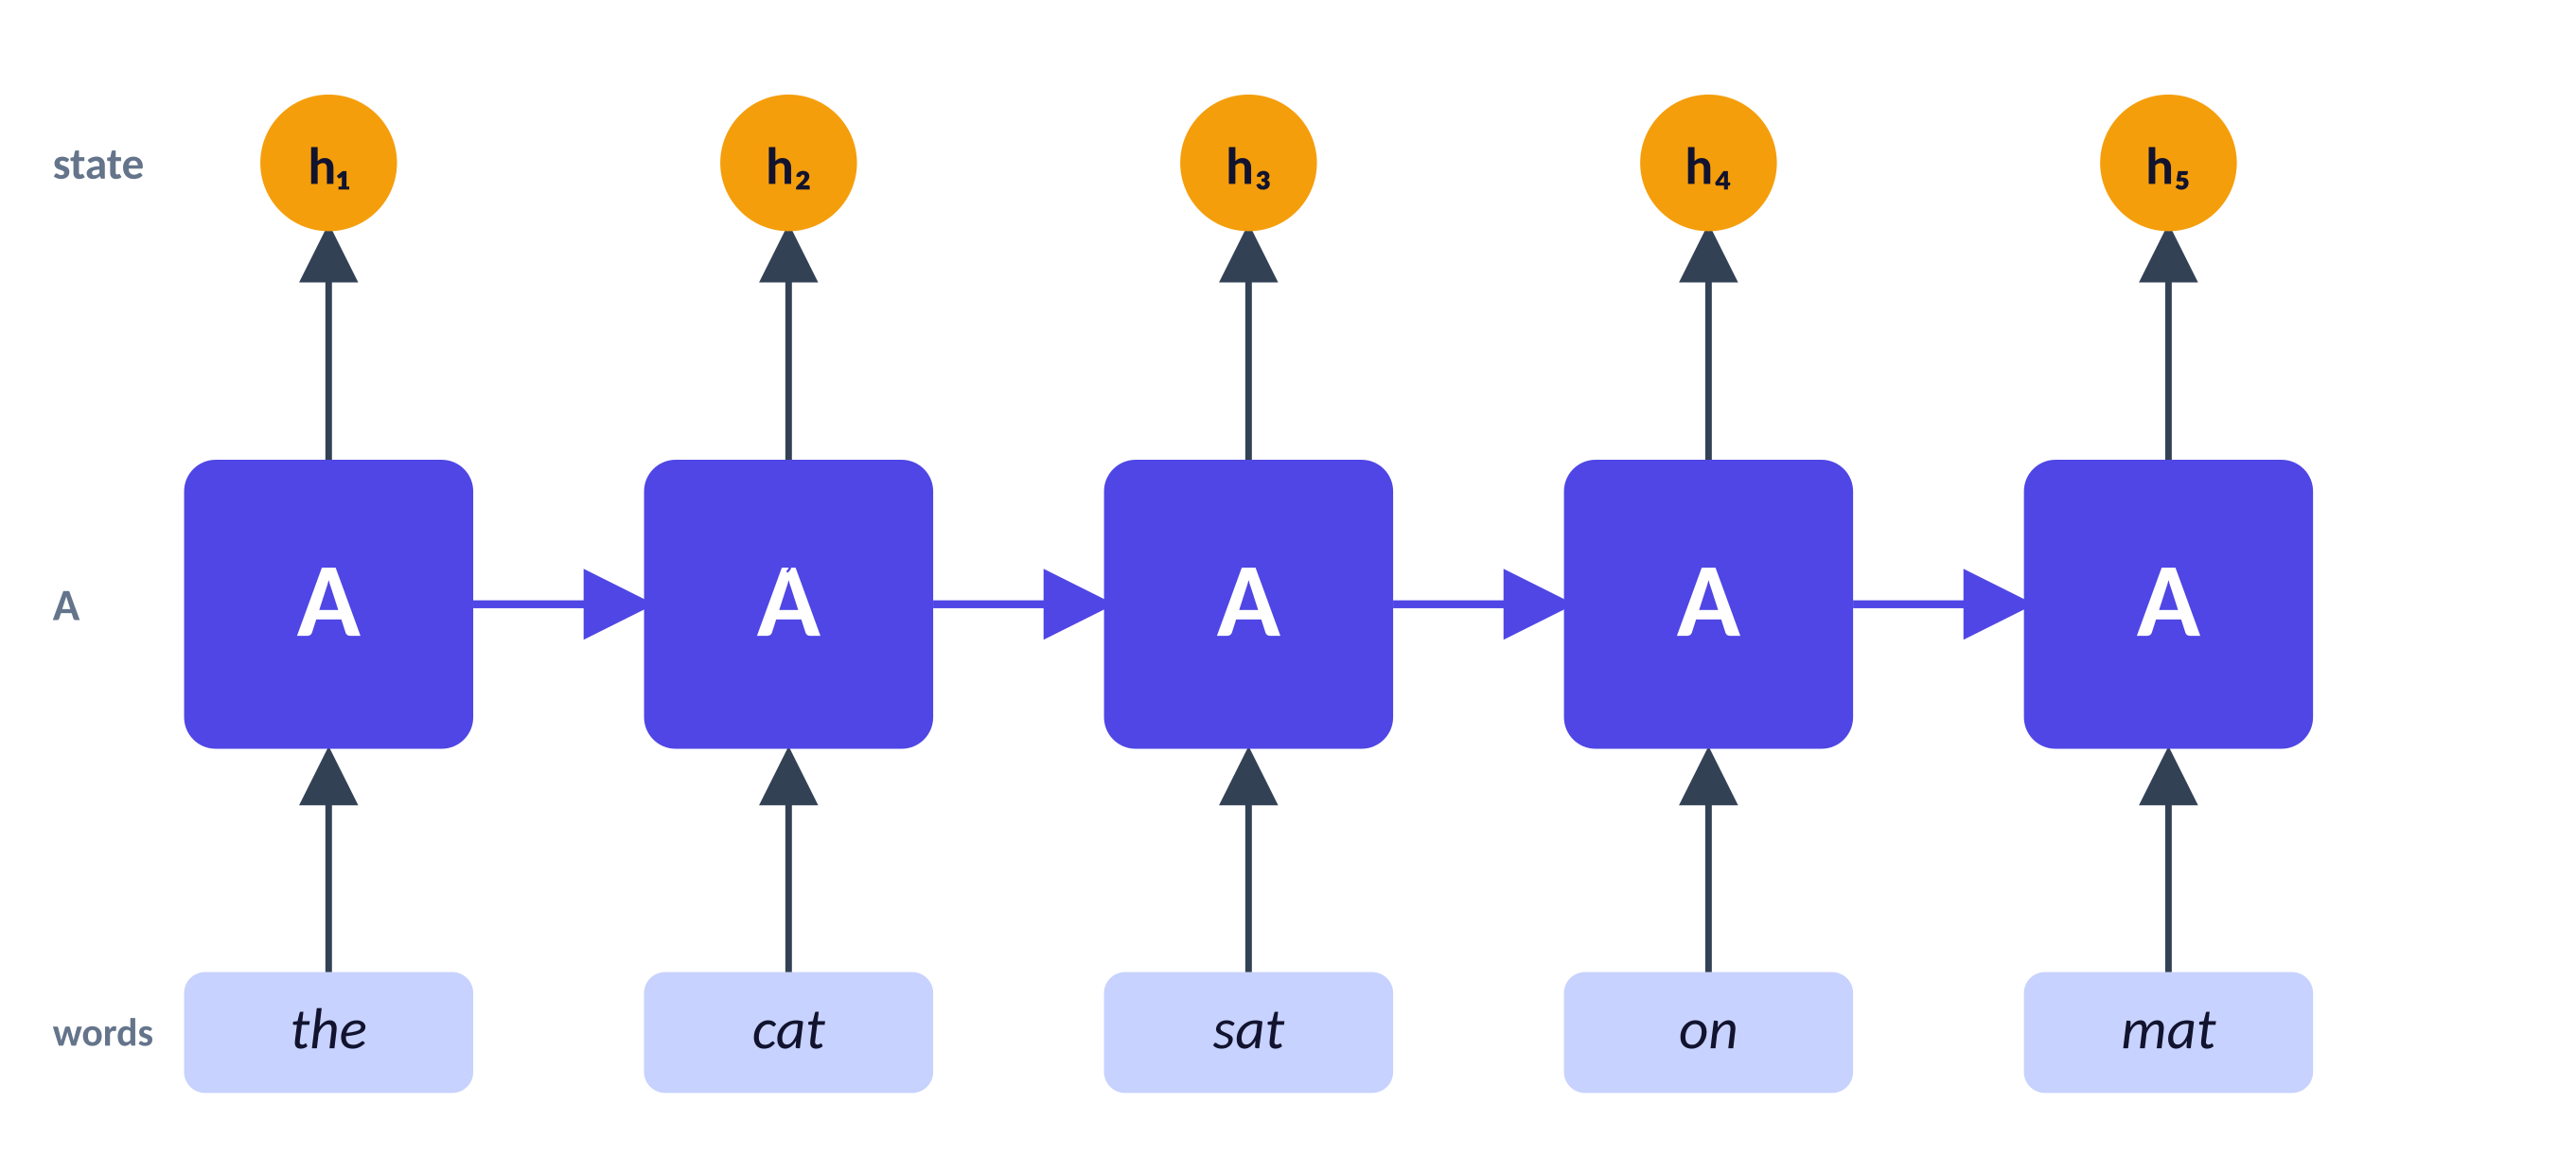<div style="color:#64748B;font-size:13px;font-style:italic;margin-top:6px">return_sequences=False keeps only the last green state; =True keeps all of them.</div></div>

In [ ]:
from tensorflow.keras.layers import Flatten

def model_false():   # last state only
    return Sequential([Input((look_back, 1)),
                       LSTM(32, return_sequences=___),     # TODO: which value?
                       Dense(1)])

def model_true():    # every state -> Flatten -> Dense
    return Sequential([Input((look_back, 1)),
                       LSTM(32, return_sequences=___),     # TODO: which value?
                       Flatten(),
                       Dense(1)])

for name, b in [('return_sequences=False', model_false), ('return_sequences=True', model_true)]:
    tf.random.set_seed(7)
    m = b(); m.compile(loss='mse', optimizer='adam')
    m.fit(trainX, trainY, epochs=40, batch_size=32, validation_split=0.1, verbose=0)
    p = m.predict(testX, verbose=0)
    rmse = float(np.sqrt(np.mean((inv(p[:,0]) - inv(testY))**2)))
    print(f"{name:24s} | params {m.count_params():5d} | test RMSE ${rmse:.2f}")

<div style="background:#FFF7ED;border:1px solid #F59E0B55;border-left:5px solid #F59E0B;border-radius:10px;padding:12px 16px;margin:10px 0"><div style="color:#F59E0B;font-weight:700;font-size:15px;margin-bottom:4px">❓ Question</div><div style="color:#1f2937;font-size:15px;line-height:1.5"><b>Q1.2</b> — How does the <b>parameter count</b> change between the two flags, and why? Did keeping every state improve the RMSE? When is <code>return_sequences=True</code> <i>necessary</i>?<br><br><i>Your answer:</i> ...</div></div>

<div style="background:#FDF2F8;border:1px solid #E11D4855;border-left:5px solid #E11D48;border-radius:10px;padding:12px 16px;margin:10px 0"><div style="color:#E11D48;font-weight:700;font-size:15px;margin-bottom:4px">🔑 Key idea</div><div style="color:#1f2937;font-size:15px;line-height:1.5">On this <b>short-horizon</b> task all three cells are excellent (~2–3$ error on a ~110$ stock) and the <b>SimpleRNN is competitive with the fewest parameters</b>. The gating of LSTM/GRU pays off for <b>long</b> dependencies — exactly what the next parts test.</div></div>

<div style="border-left:5px solid #4F46E5;padding:6px 0 6px 12px;margin:14px 0 4px 0"><span style="color:#12132E;font-size:21px;font-weight:700">📌 Interpretation — Q1.3</span></div>**Which cell wins here, and why?** Look at the RMSE *and* the parameter columns. Is the most complex model the best? Why might a SimpleRNN suffice for **next-day** forecasting? When would LSTM/GRU clearly help?<br><br>*Your answer:* ...

<div style="background:linear-gradient(100deg,#7C3AED 0%,#12132E 100%);border-radius:14px;padding:20px 26px;margin:6px 0 2px 0"><div style="color:#FFFFFFcc;font-size:14px;font-weight:700;letter-spacing:2px">PART 2</div><div style="color:#FFFFFF;font-size:30px;font-weight:800;line-height:1.15;margin-top:2px">Text generation with GRU (and + Attention)</div><div style="color:#FFFFFFcc;font-size:16px;font-style:italic;margin-top:6px">📝 text data — predict the next character, then generate poems</div></div>

<div align="center">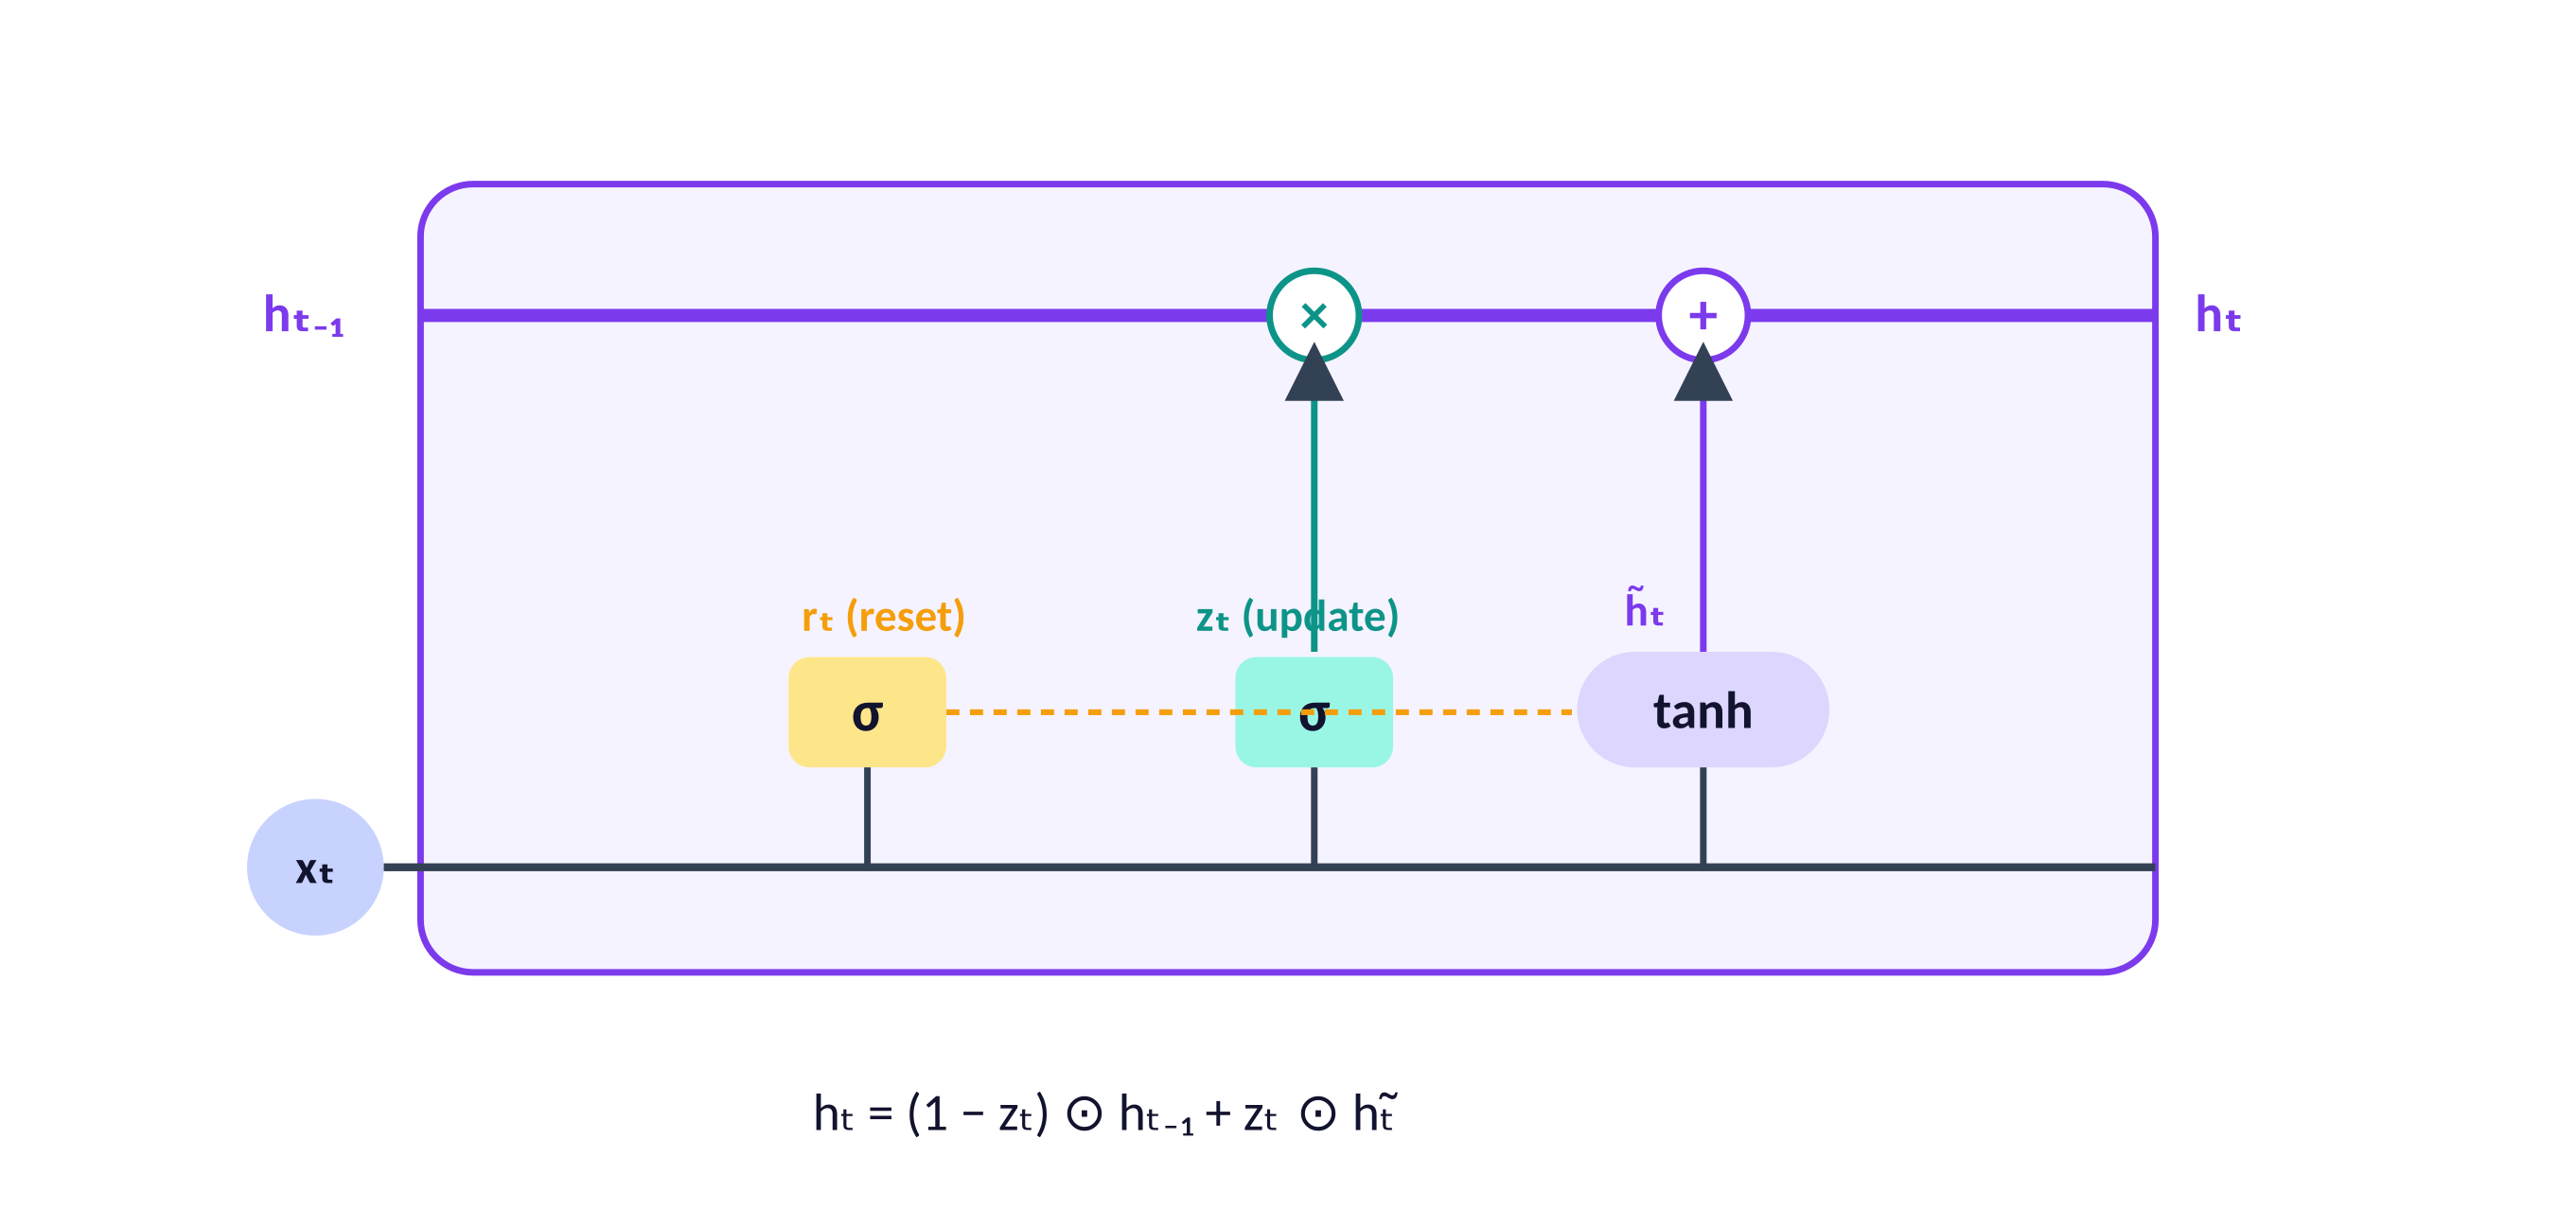<div style="color:#64748B;font-size:13px;font-style:italic;margin-top:6px">The GRU cell: an update gate z and a reset gate r over a single hidden state.</div></div>

<div style="border-left:5px solid #7C3AED;padding:6px 0 6px 12px;margin:14px 0 4px 0"><span style="color:#12132E;font-size:21px;font-weight:700">2.1 — 🧱 Preparing TEXT for a character model</span></div>

<div style="background:#EEF2FF;border:1px solid #4F46E555;border-left:5px solid #4F46E5;border-radius:10px;padding:12px 16px;margin:10px 0"><div style="color:#4F46E5;font-weight:700;font-size:15px;margin-bottom:4px">🧱 Data preparation</div><div style="color:#1f2937;font-size:15px;line-height:1.5">We model text <b>one character at a time</b>. Steps:<ul><li>Build the <b>vocabulary</b> = the sorted set of unique characters, and two maps <code>char→index</code> / <code>index→char</code>.</li><li>Cut the text into overlapping <b>windows</b> of <code>max_length</code> characters; the target is the <b>single next character</b>.</li><li><b>One-hot encode</b>: each character becomes a vector of zeros with a single 1 at its vocabulary slot. <code>X</code> is then <code>(n_windows, max_length, vocab)</code> and <code>y</code> is <code>(n_windows, vocab)</code>.</li></ul></div></div>

<div align="center">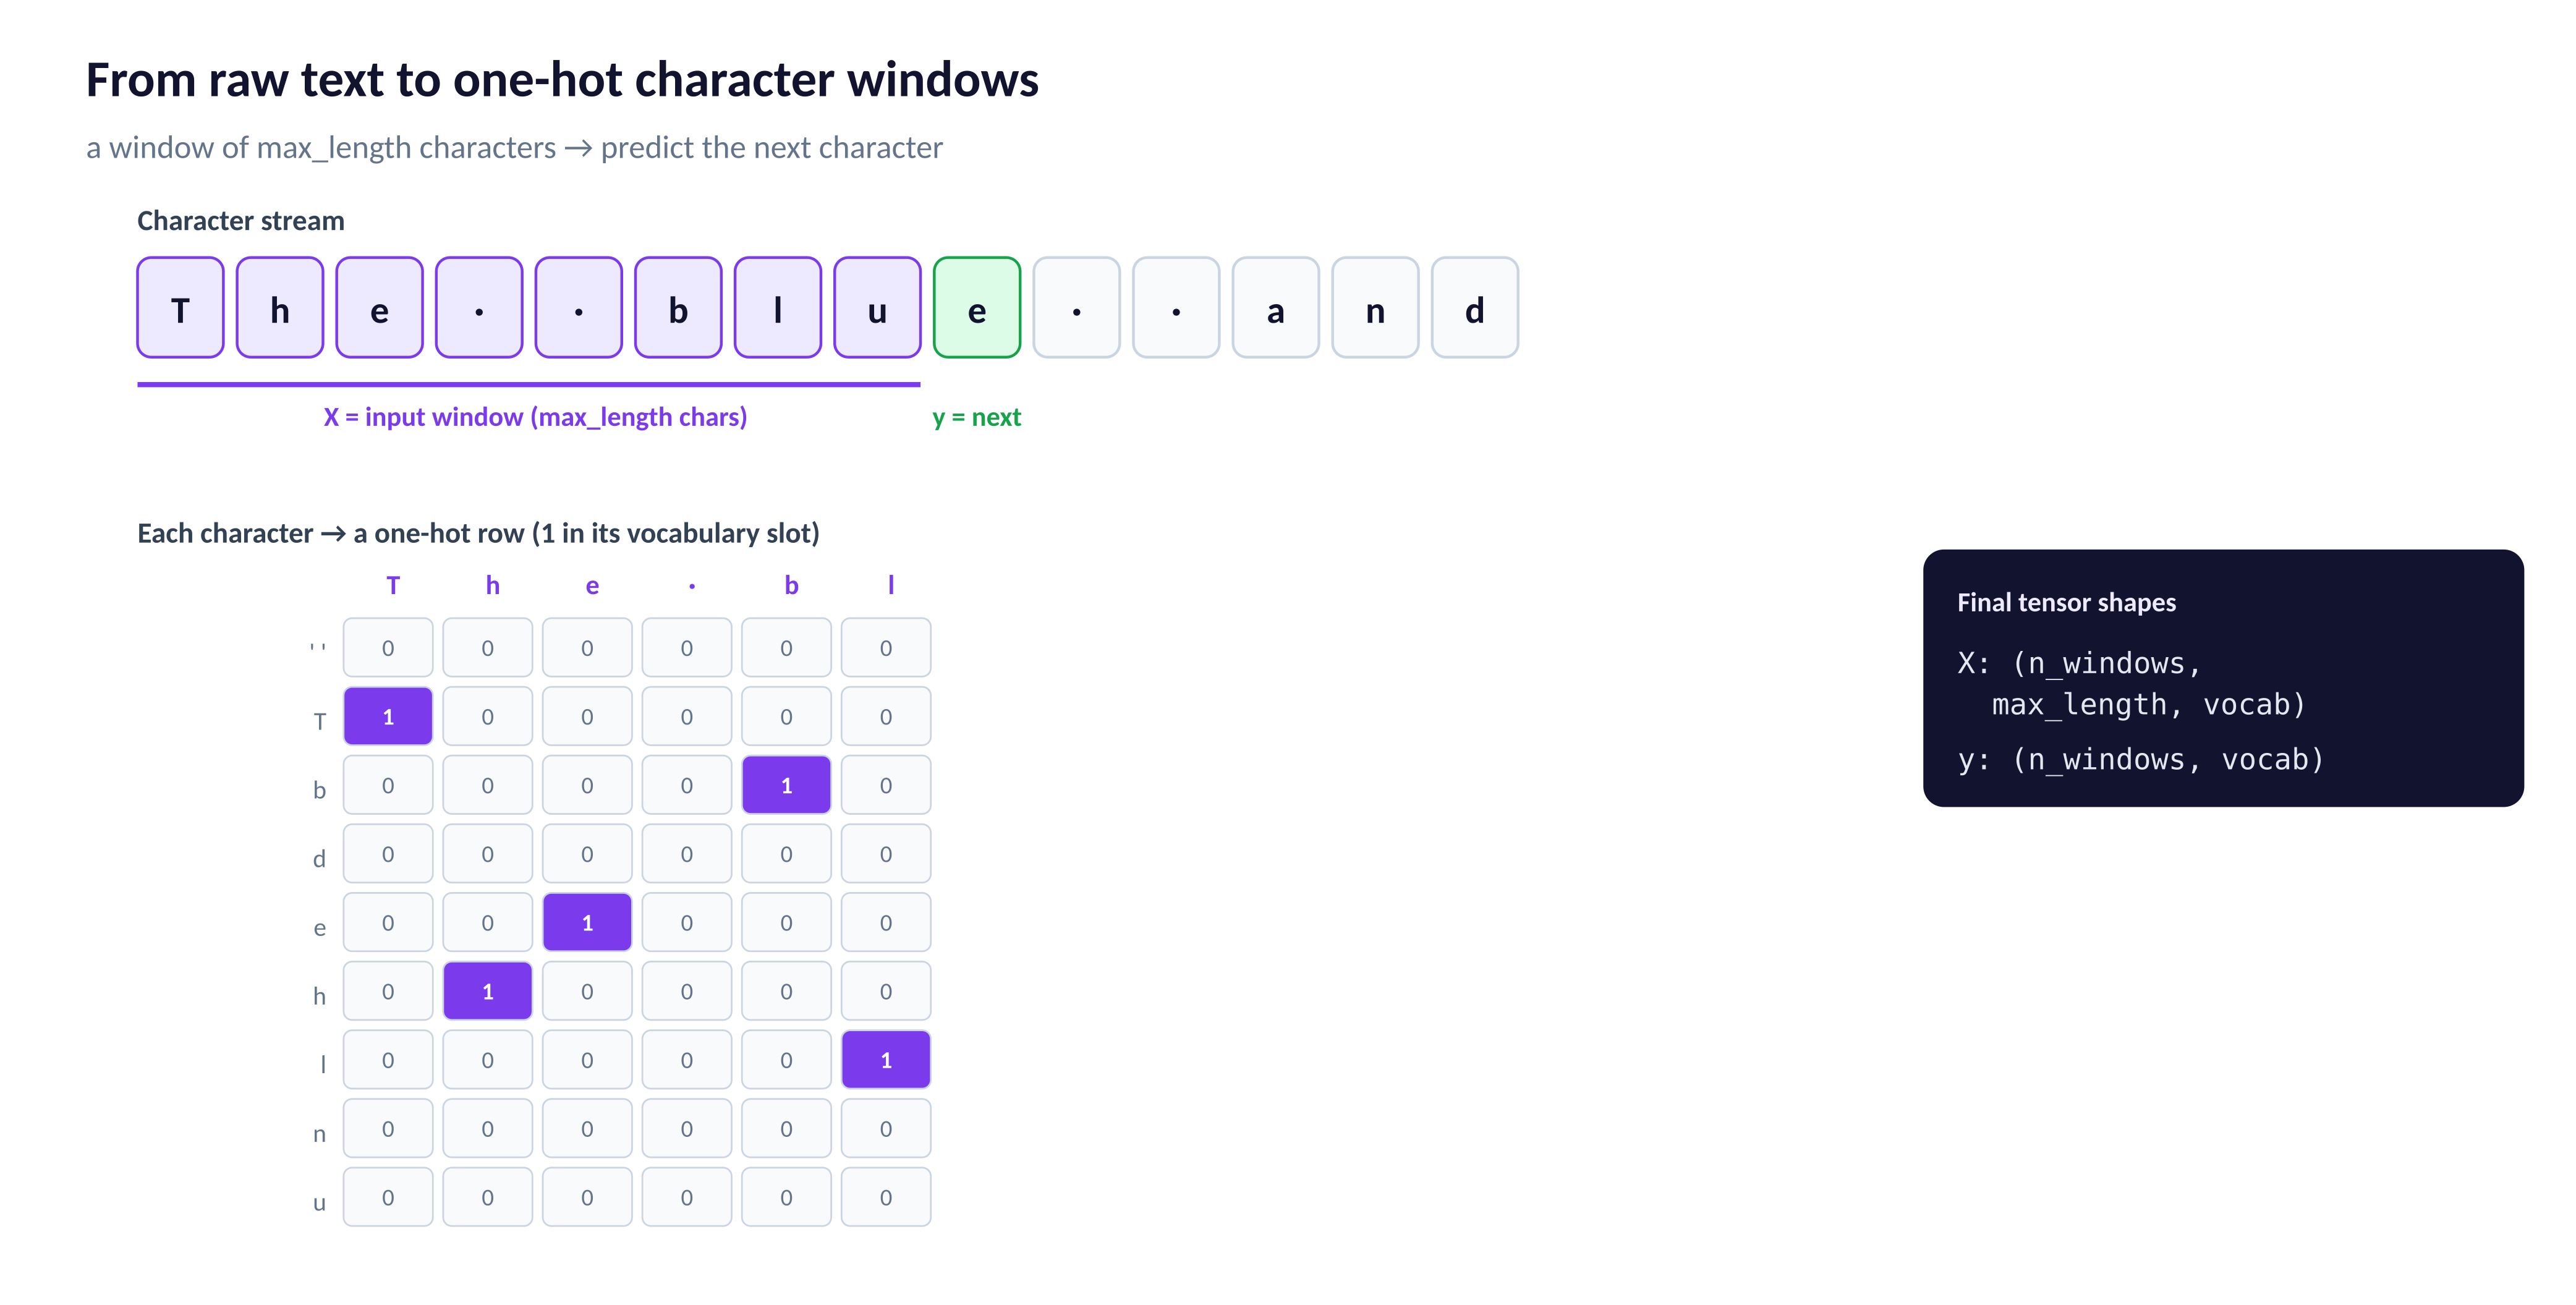<div style="color:#64748B;font-size:13px;font-style:italic;margin-top:6px">Each character → a one-hot row; a window of characters → the next character.</div></div>

<div style="border-left:5px solid #7C3AED;padding:6px 0 6px 12px;margin:14px 0 4px 0"><span style="color:#12132E;font-size:21px;font-weight:700">2.2 — Build the character vocabulary</span></div>

In [ ]:
with open('poems.txt', 'r') as f:
    text = f.read()
print(text[:200], "...\n")

vocab = sorted(set(text))
char2idx = {c: i for i, c in enumerate(vocab)}
idx2char = {i: c for i, c in enumerate(vocab)}
V = len(vocab)
print("text length:", len(text), "| vocabulary size:", V)

<div style="border-left:5px solid #7C3AED;padding:6px 0 6px 12px;margin:14px 0 4px 0"><span style="color:#12132E;font-size:21px;font-weight:700">2.3 — One-hot encode overlapping windows</span></div>

In [ ]:
max_length, step = 100, 3
sentences, next_chars = [], []
for i in range(0, len(text) - max_length, step):
    sentences.append(text[i:i+max_length]); next_chars.append(text[i+max_length])

X = np.zeros((len(sentences), max_length, V), dtype=bool)
y = np.zeros((len(sentences), V), dtype=bool)
for i, s in enumerate(sentences):
    for t, ch in enumerate(s):
        X[i, t, char2idx[ch]] = 1
    y[i, char2idx[next_chars[i]]] = 1
print("X", X.shape, "| y", y.shape)

<div style="background:#FFF7ED;border:1px solid #F59E0B55;border-left:5px solid #F59E0B;border-radius:10px;padding:12px 16px;margin:10px 0"><div style="color:#F59E0B;font-weight:700;font-size:15px;margin-bottom:4px">❓ Question</div><div style="color:#1f2937;font-size:15px;line-height:1.5"><b>Q2.1</b> — Roughly how many windows do you get? What does <code>step</code> control (trade-off of <code>step=1</code> vs larger)?<br><br><i>Your answer:</i> ...</div></div>

<div style="border-left:5px solid #7C3AED;padding:6px 0 6px 12px;margin:14px 0 4px 0"><span style="color:#12132E;font-size:21px;font-weight:700">2.4 — A plain GRU language model</span></div>Notice <b>return_sequences is left to its default (False)</b>: we only need the last state to predict one next character.

In [ ]:
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import GRU, Dense, Activation, Input, Attention, Lambda
from tensorflow.keras.optimizers import RMSprop

def gru_model():
    # TODO: Input -> GRU(128) -> Dense(V) -> softmax
    m = Sequential([ ___ ])
    m.compile(loss='categorical_crossentropy', optimizer=RMSprop())
    return m

gru = gru_model()
gru.fit(X, y, batch_size=128, epochs=40, verbose=0, callbacks=[LivePlotLoss("GRU text")])
print("final loss:", round(gru.history.history['loss'][-1], 3))

<div style="border-left:5px solid #7C3AED;padding:6px 0 6px 12px;margin:14px 0 4px 0"><span style="color:#12132E;font-size:21px;font-weight:700">2.5 — Sampling with a <i>temperature</i> (diversity)</span></div>

In [ ]:
def sample_index(preds, temperature=1.0):
    preds = np.asarray(preds).astype('float64')
    preds = np.log(preds + 1e-9) / temperature
    exp = np.exp(preds); preds = exp / exp.sum()
    return np.argmax(np.random.multinomial(1, preds, 1))

def generate_text(model, length=240, diversity=0.5):
    start = np.random.randint(0, len(text) - max_length - 1)
    sentence = text[start:start+max_length]; generated = sentence
    for _ in range(length):
        x_pred = np.zeros((1, max_length, V))
        for t, ch in enumerate(sentence):
            x_pred[0, t, char2idx[ch]] = 1.
        preds = model.predict(x_pred, verbose=0)[0]
        nxt = idx2char[sample_index(preds, diversity)]
        generated += nxt; sentence = sentence[1:] + nxt
    return generated

for d in [0.2, 0.5, 1.0]:
    print(f"\n----- diversity = {d} -----")
    print(generate_text(gru, 200, d))

<div style="background:#FFF7ED;border:1px solid #F59E0B55;border-left:5px solid #F59E0B;border-radius:10px;padding:12px 16px;margin:10px 0"><div style="color:#F59E0B;font-weight:700;font-size:15px;margin-bottom:4px">❓ Question</div><div style="color:#1f2937;font-size:15px;line-height:1.5"><b>Q2.2</b> — Compare diversity 0.2 / 0.5 / 1.0. How does the text change? Where is the sweet spot?<br><br><i>Your answer:</i> ...</div></div>

<div style="border-left:5px solid #7C3AED;padding:6px 0 6px 12px;margin:14px 0 4px 0"><span style="color:#12132E;font-size:21px;font-weight:700">2.6 — The same model <b>with self-attention</b> (RNN + Attention)</span></div>Here we set <b><code>return_sequences=True</code></b> so attention can see <i>every</i> step, then pool the result.

In [ ]:
def gru_attention_model():
    inp = Input((max_length, V))
    # TODO: GRU(128) returning the FULL sequence (why must return_sequences be True here?)
    g = ___
    # TODO: self-attention over g  ->  Attention()([g, g])
    a = ___
    ctx = Lambda(lambda z: tf.reduce_mean(z, axis=1))(a)
    out = Dense(V, activation='softmax')(ctx)
    m = Model(inp, out)
    m.compile(loss='categorical_crossentropy', optimizer=RMSprop())
    return m

gru_attn = gru_attention_model()
gru_attn.fit(X, y, batch_size=128, epochs=40, verbose=0, callbacks=[LivePlotLoss("GRU+Attention")])
print("final loss:", round(gru_attn.history.history['loss'][-1], 3))

<div style="background:#FFF7ED;border:1px solid #F59E0B55;border-left:5px solid #F59E0B;border-radius:10px;padding:12px 16px;margin:10px 0"><div style="color:#F59E0B;font-weight:700;font-size:15px;margin-bottom:4px">❓ Question</div><div style="color:#1f2937;font-size:15px;line-height:1.5"><b>Q2.3</b> — Why is <code>return_sequences=True</code> mandatory for the attention model but not the plain GRU? What shape is <code>g</code> in each case?<br><br><i>Your answer:</i> ...</div></div>

<div style="border-left:5px solid #7C3AED;padding:6px 0 6px 12px;margin:14px 0 4px 0"><span style="color:#12132E;font-size:21px;font-weight:700">📌 Interpretation — Q2.4</span></div>**Did attention help here?** Compare the two final losses and the samples. Why might attention **not** help on such a small dataset? What does *mean-pooling* throw away?<br><br>*Your answer:* ...

<div style="background:linear-gradient(100deg,#E11D48 0%,#12132E 100%);border-radius:14px;padding:20px 26px;margin:6px 0 2px 0"><div style="color:#FFFFFFcc;font-size:14px;font-weight:700;letter-spacing:2px">PART 3</div><div style="color:#FFFFFF;font-size:30px;font-weight:800;line-height:1.15;margin-top:2px">Why attention? A controlled experiment</div><div style="color:#FFFFFFcc;font-size:16px;font-style:italic;margin-top:6px">🎯 a task that REQUIRES looking far back — where attention clearly wins</div></div>

<div align="center">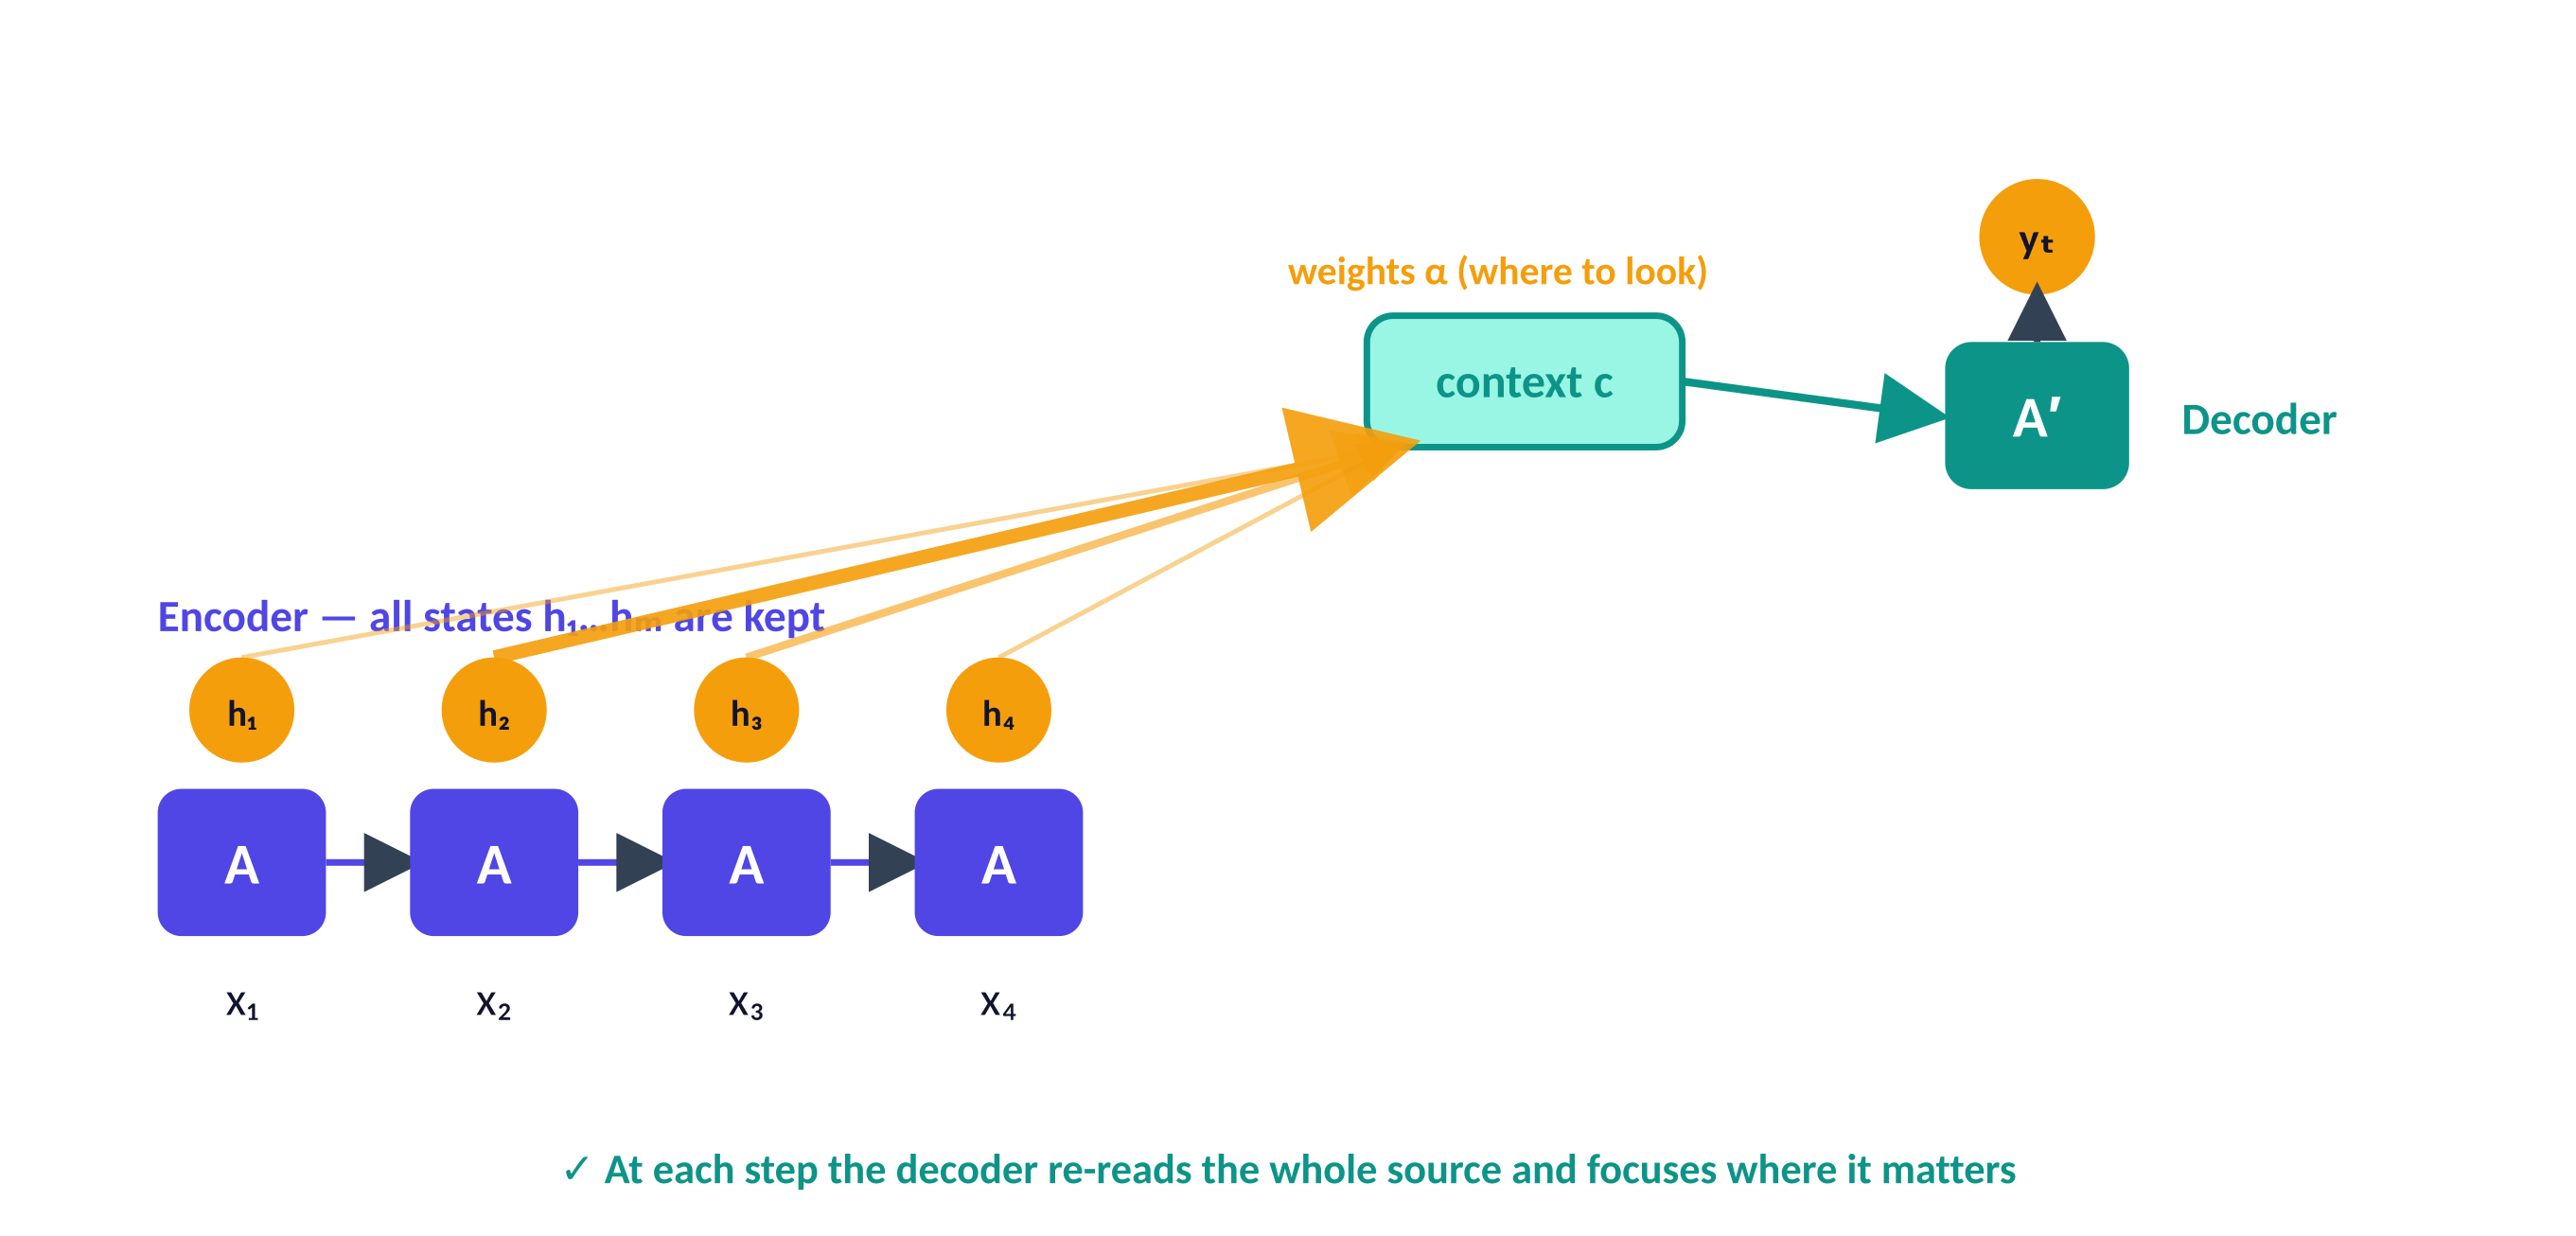<div style="color:#64748B;font-size:13px;font-style:italic;margin-top:6px">Attention lets the model read every state and focus where it matters (weights α).</div></div>

<div style="border-left:5px solid #E11D48;padding:6px 0 6px 12px;margin:14px 0 4px 0"><span style="color:#12132E;font-size:21px;font-weight:700">3.1 — 🧱 Preparing the <i>pointer</i> task</span></div>

<div style="background:#EEF2FF;border:1px solid #4F46E555;border-left:5px solid #4F46E5;border-radius:10px;padding:12px 16px;margin:10px 0"><div style="color:#4F46E5;font-weight:700;font-size:15px;margin-bottom:4px">🧱 Data preparation</div><div style="color:#1f2937;font-size:15px;line-height:1.5">We <b>generate</b> the data so we control exactly what memory is needed:<ul><li>A sequence of <code>T = 25</code> random digits.</li><li><b>Position 0 stores a pointer</b> <code>p</code> (a number in 1…T-1).</li><li>The <b>target</b> is the digit located <b>at position p</b> — i.e. <code>target = sequence[p]</code>.</li></ul>To answer, the model must read the pointer and then <b>jump to a far-away position</b>. A last-state RNN must cram all 25 positions into one vector; attention can look straight at position <code>p</code>.</div></div>

<div style="border-left:5px solid #E11D48;padding:6px 0 6px 12px;margin:14px 0 4px 0"><span style="color:#12132E;font-size:21px;font-weight:700">3.2 — Generate the data</span></div>

In [ ]:
T, NSYM, N = 25, 10, 12000
def make_data(n):
    seq = np.random.randint(0, NSYM, size=(n, T))
    p = np.random.randint(1, T, size=n)     # pointer in [1, T-1]
    seq[:, 0] = p                           # store the pointer at position 0
    y = seq[np.arange(n), p]                # target = digit at the pointed position
    return seq, y, p

X, y, ptr = make_data(N)
Xtr, ytr = X[:10000], y[:10000]
Xte, yte, pte = X[10000:], y[10000:], ptr[10000:]
print("example sequence:", X[0]); print("pointer p =", ptr[0], "-> target =", y[0])

<div style="border-left:5px solid #E11D48;padding:6px 0 6px 12px;margin:14px 0 4px 0"><span style="color:#12132E;font-size:21px;font-weight:700">3.3 — Two models: last-state RNN vs RNN + attention</span></div>The attention pooling below is a small <b>additive (Bahdanau-style)</b> attention that also <b>returns the weights α</b>, so we can see <i>where</i> the model looks. It needs <code>return_sequences=True</code> to get every state.

In [ ]:
from tensorflow.keras.layers import Input, Embedding, GRU, Dense, Layer
from tensorflow.keras.models import Model

class AttnPool(Layer):
    def __init__(self, units=64, **kw):
        super().__init__(**kw); self.W = Dense(units); self.v = Dense(1)
    def call(self, h):                       # h: (B, T, H)
        score = self.v(tf.tanh(self.W(h)))   # (B, T, 1)
        # TODO: softmax over the TIME axis (axis=1) so weights sum to 1
        alpha = ___
        # TODO: context = weighted sum of h over time
        context = ___
        return context, alpha[..., 0]

def build_pointer(use_attention):
    inp = Input((T,))
    e = Embedding(NSYM + T, 32)(inp)
    if use_attention:
        h = GRU(64, return_sequences=___)(e)    # TODO: keep ALL states?
        ctx, alpha = AttnPool(64)(h)
        out = Dense(NSYM, activation='softmax')(ctx)
        return Model(inp, [out, alpha])
    else:
        h = GRU(64)(e)                          # last state only
        return Model(inp, Dense(NSYM, activation='softmax')(h))

<div style="border-left:5px solid #E11D48;padding:6px 0 6px 12px;margin:14px 0 4px 0"><span style="color:#12132E;font-size:21px;font-weight:700">3.4 — Train both and compare accuracy</span></div>

In [ ]:
# no attention
tf.random.set_seed(0)
m0 = build_pointer(False)
m0.compile(loss='sparse_categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
h0 = m0.fit(Xtr, ytr, epochs=15, batch_size=128, validation_split=0.1, verbose=0)
acc0 = m0.evaluate(Xte, yte, verbose=0)[1]

# with attention (loss only on the class output, not on alpha)
tf.random.set_seed(0)
m1 = build_pointer(True)
m1.compile(loss=['sparse_categorical_crossentropy', None], optimizer='adam',
           metrics=[['accuracy'], []])
h1 = m1.fit(Xtr, ytr, epochs=15, batch_size=128, validation_split=0.1, verbose=0)
acc1 = m1.evaluate(Xte, yte, verbose=0)[1]

print(f"RNN (last state)  test accuracy: {acc0:.3f}")
print(f"RNN + attention   test accuracy: {acc1:.3f}")

<div style="border-left:5px solid #E11D48;padding:6px 0 6px 12px;margin:14px 0 4px 0"><span style="color:#12132E;font-size:21px;font-weight:700">3.5 — Visualize <i>where</i> attention looks</span></div>

In [ ]:
preds, alphas = m1.predict(Xte[:6], verbose=0)
fig, axes = plt.subplots(6, 1, figsize=(8, 7), sharex=True)
for k in range(6):
    axes[k].bar(range(T), alphas[k], color='#E11D48')
    axes[k].axvline(pte[k], color='#0D9488', lw=2, ls='--')   # true target position
    axes[k].set_yticks([]); axes[k].set_ylabel(f"p={pte[k]}", rotation=0, labelpad=22, va='center')
axes[0].set_title('Attention weights per position (dashed teal = pointer target)')
axes[-1].set_xlabel('position'); plt.tight_layout(); plt.show()

<div style="background:#FFF7ED;border:1px solid #F59E0B55;border-left:5px solid #F59E0B;border-radius:10px;padding:12px 16px;margin:10px 0"><div style="color:#F59E0B;font-weight:700;font-size:15px;margin-bottom:4px">❓ Question</div><div style="color:#1f2937;font-size:15px;line-height:1.5"><b>Q3.1</b> — Fill the accuracy table below and explain. Where does the red mass sit vs the dashed line?<br><br>| Model | Test accuracy |<br>|---|---|<br>| RNN (last state) | ... |<br>| RNN + attention | ... |<br><br><i>Your answer:</i> ...</div></div>

<div style="background:#FFF7ED;border:1px solid #F59E0B55;border-left:5px solid #F59E0B;border-radius:10px;padding:12px 16px;margin:10px 0"><div style="color:#F59E0B;font-weight:700;font-size:15px;margin-bottom:4px">❓ Question</div><div style="color:#1f2937;font-size:15px;line-height:1.5"><b>Q3.2 (deeper)</b> — Increase <code>T</code> to 40 and re-run. How does each model scale with sequence length? Relate it to the bottleneck problem and the O(m·t) cost of attention.<br><br><i>Your answer:</i> ...</div></div>

<div style="border-left:5px solid #E11D48;padding:6px 0 6px 12px;margin:14px 0 4px 0"><span style="color:#12132E;font-size:21px;font-weight:700">📌 Interpretation — Q3.3</span></div>Summarize: why does the last-state RNN struggle, and what makes attention succeed *and* interpretable?<br><br>*Your answer:* ...

<div style="background:linear-gradient(100deg,#0D9488 0%,#12132E 100%);border-radius:14px;padding:20px 26px;margin:6px 0 2px 0"><div style="color:#FFFFFFcc;font-size:14px;font-weight:700;letter-spacing:2px">PART 4</div><div style="color:#FFFFFF;font-size:30px;font-weight:800;line-height:1.15;margin-top:2px">Music generation with an LSTM</div><div style="color:#FFFFFFcc;font-size:16px;font-style:italic;margin-top:6px">🎵 audio — learn ABC notation char-by-char and compose a playable tune</div></div>

<div align="center">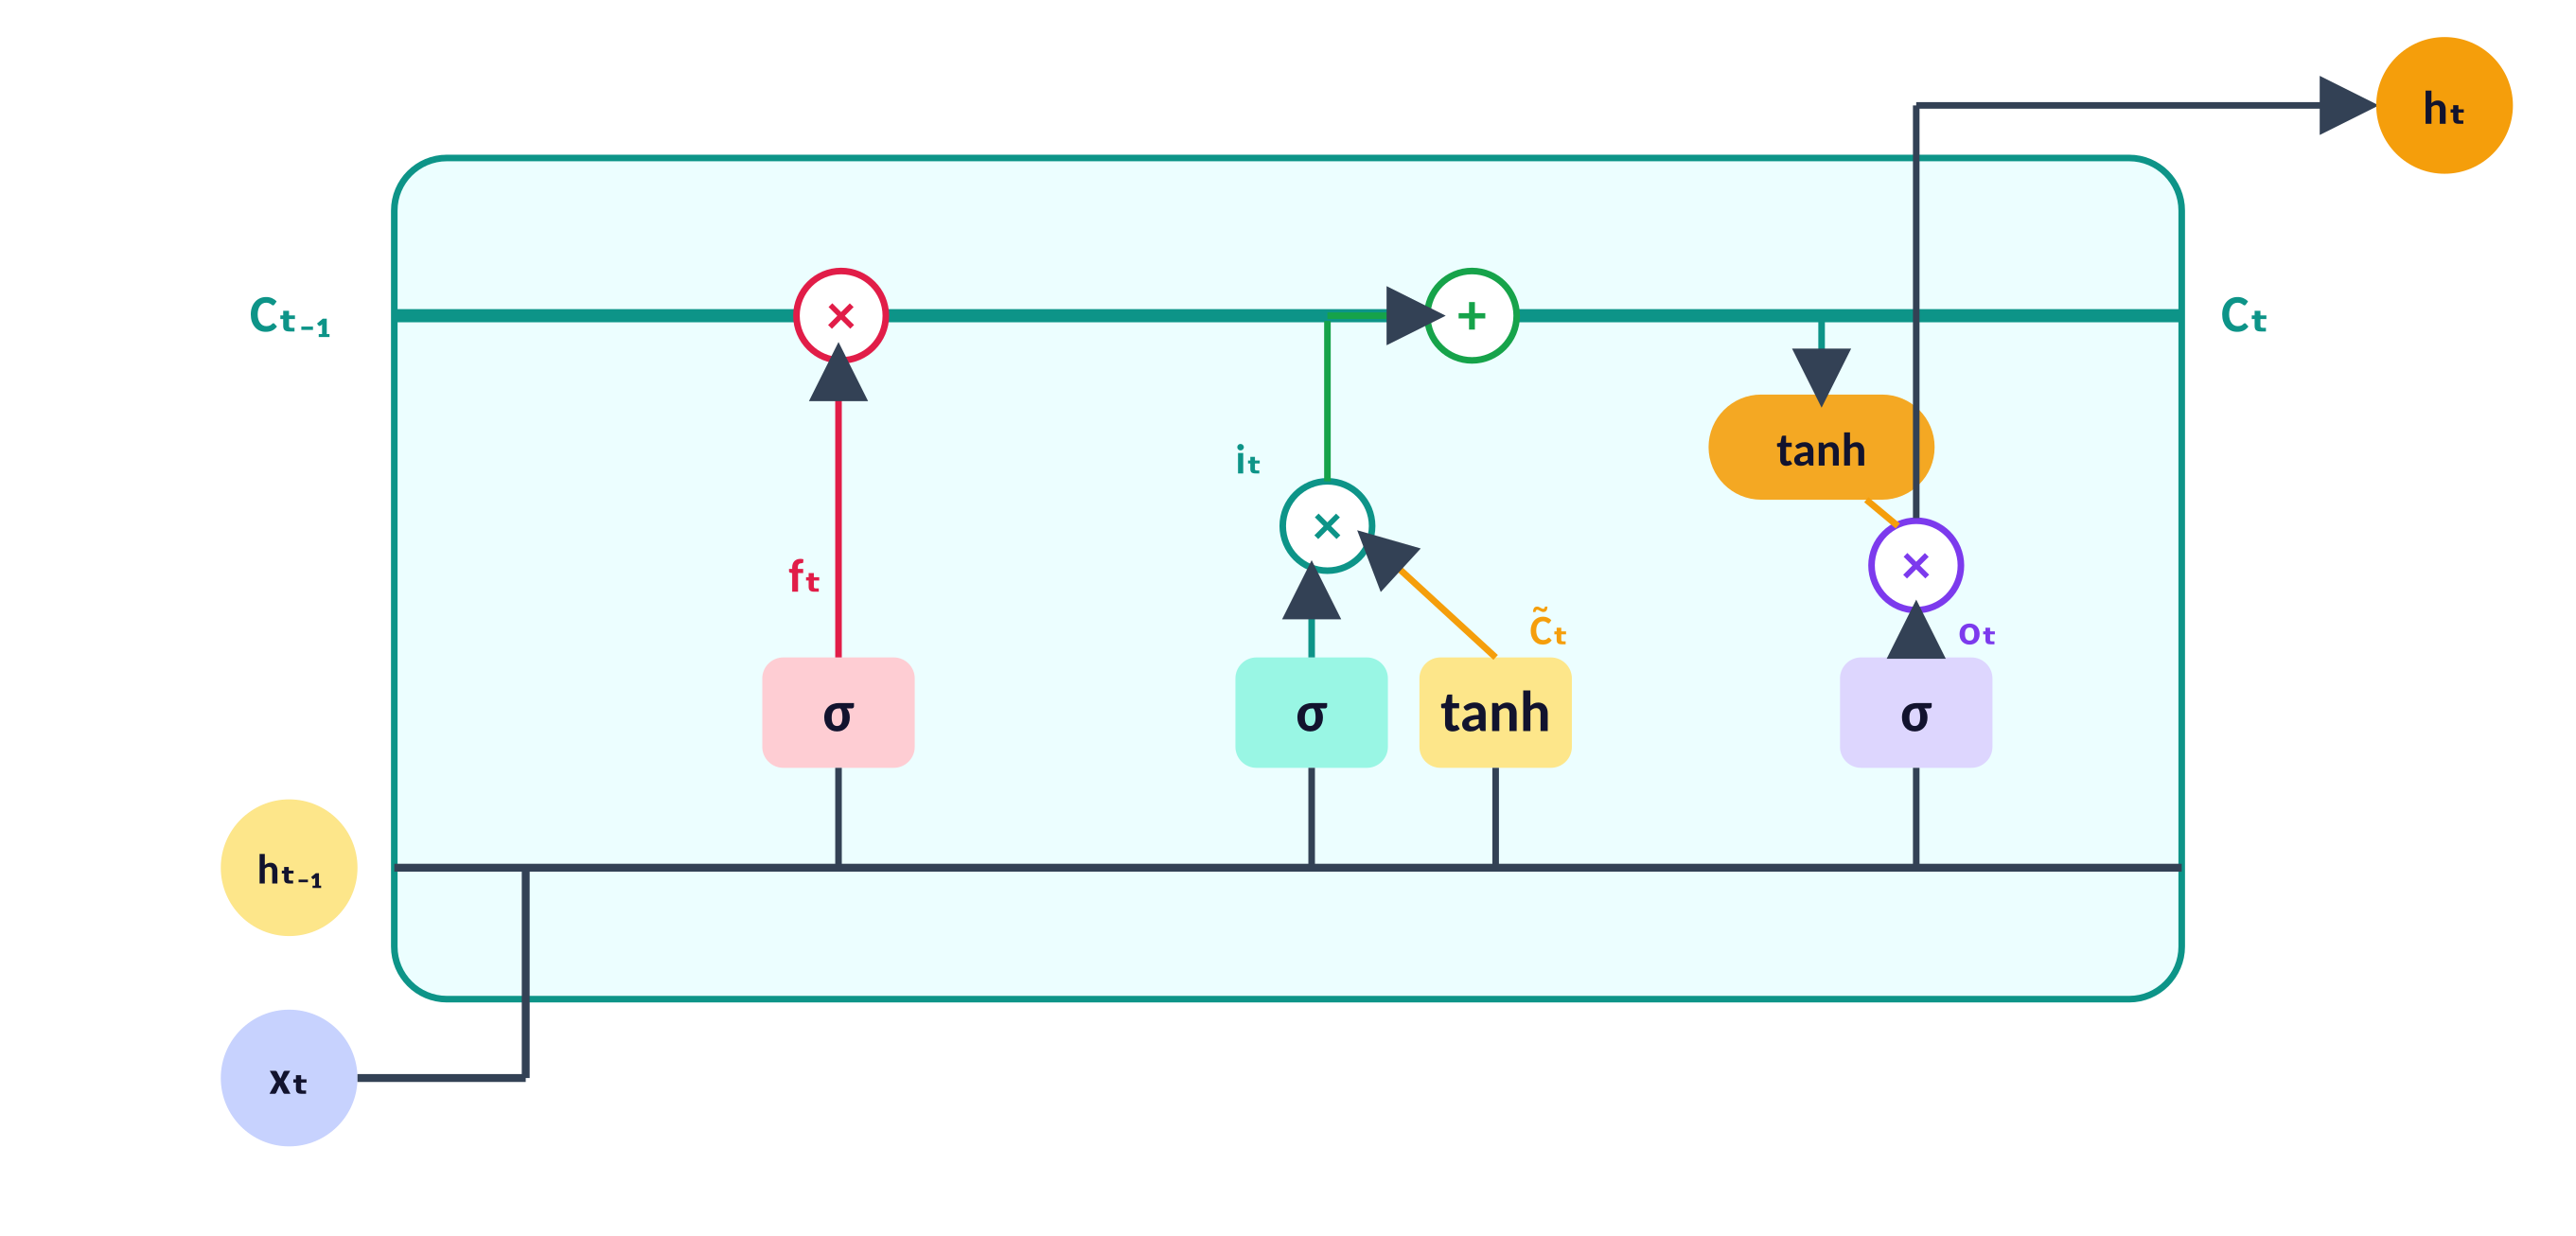<div style="color:#64748B;font-size:13px;font-style:italic;margin-top:6px">The LSTM cell: a cell-state 'conveyor belt' plus forget / input / output gates.</div></div>

<div style="background:#ECFEFF;border:1px solid #0D948855;border-left:5px solid #0D9488;border-radius:10px;padding:12px 16px;margin:10px 0"><div style="color:#0D9488;font-weight:700;font-size:15px;margin-bottom:4px">💡 Tip</div><div style="color:#1f2937;font-size:15px;line-height:1.5">Audio needs the helper <code>util.py</code> (which imports <code>regex</code>) and the system tools below.</div></div>

In [ ]:
!pip install regex > /dev/null 2>&1
!apt-get install abcmidi timidity > /dev/null 2>&1

<div style="border-left:5px solid #0D9488;padding:6px 0 6px 12px;margin:14px 0 4px 0"><span style="color:#12132E;font-size:21px;font-weight:700">4.1 — 🧱 Preparing MUSIC (sequence-to-sequence targets)</span></div>

<div style="background:#EEF2FF;border:1px solid #4F46E555;border-left:5px solid #4F46E5;border-radius:10px;padding:12px 16px;margin:10px 0"><div style="color:#4F46E5;font-weight:700;font-size:15px;margin-bottom:4px">🧱 Data preparation</div><div style="color:#1f2937;font-size:15px;line-height:1.5">Tunes are stored as text in <b>ABC notation</b>. Unlike Parts 1–2, the target here is the <b>whole input shifted by one</b>: at every position the model predicts the <b>next</b> character. Steps:<ul><li>Join all songs into one string and build the character vocabulary.</li><li><b>Vectorize</b> to integer indices (no one-hot — an <code>Embedding</code> layer will map indices to vectors).</li><li><code>get_batch</code> cuts random <code>(input, target)</code> pairs where <code>target</code> = <code>input</code> shifted by one → both have shape <code>(batch_size, seq_length)</code>.</li></ul></div></div>

<div align="center">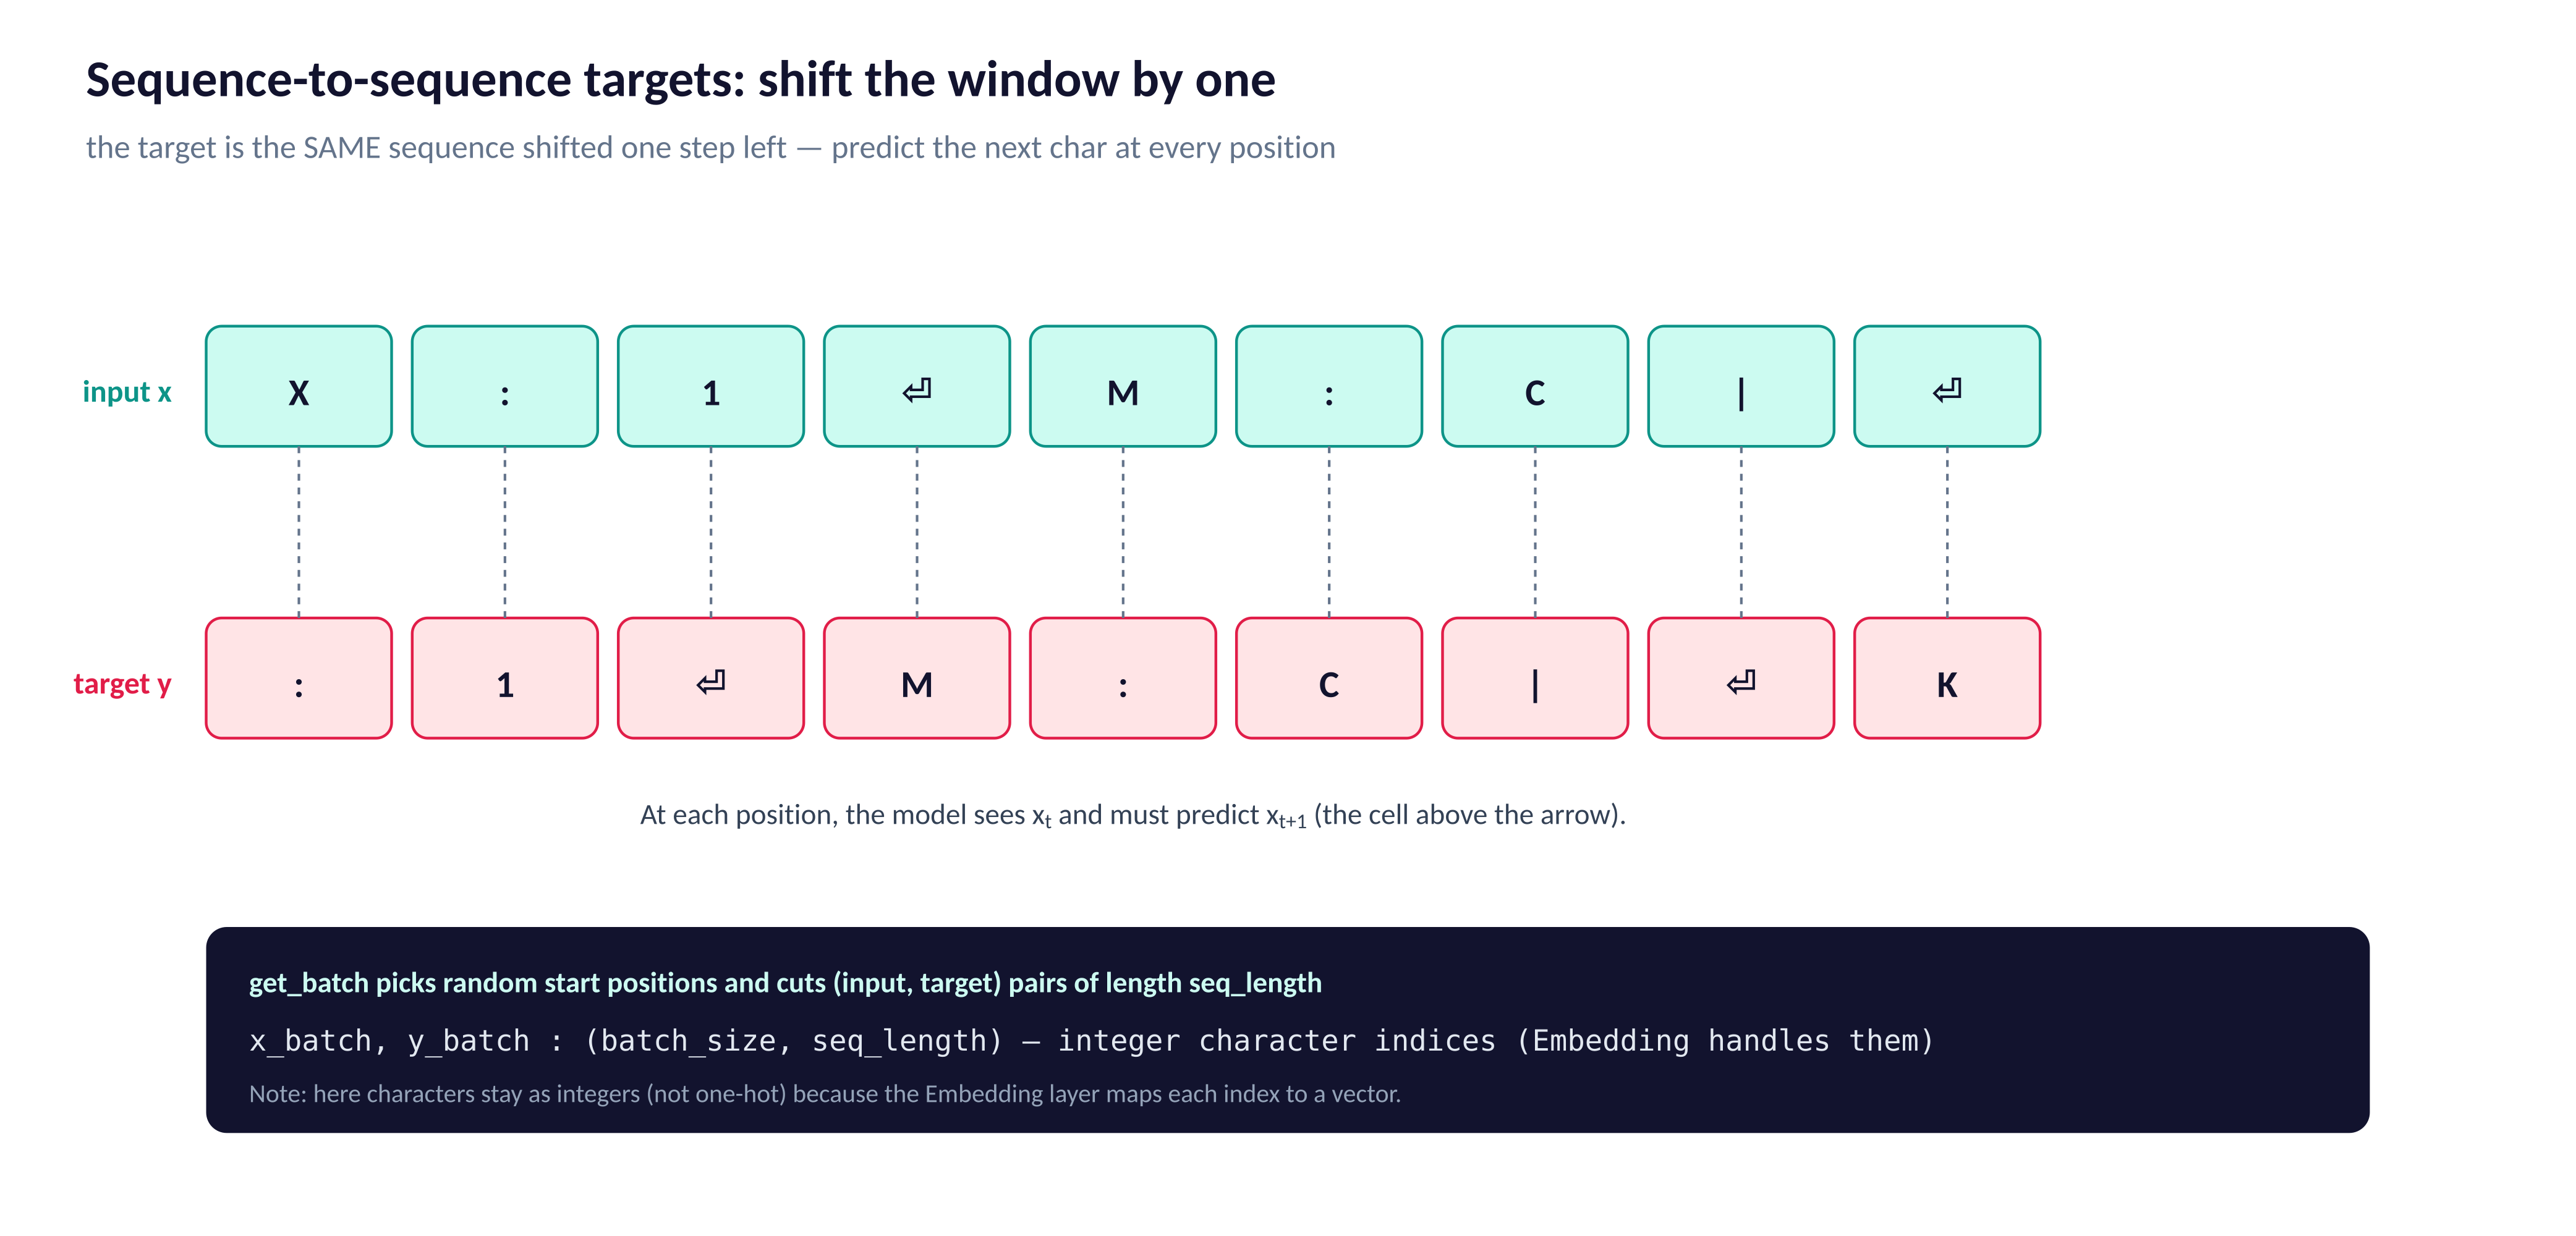<div style="color:#64748B;font-size:13px;font-style:italic;margin-top:6px">Target = input shifted one step left: predict the next character at every position.</div></div>

<div style="border-left:5px solid #0D9488;padding:6px 0 6px 12px;margin:14px 0 4px 0"><span style="color:#12132E;font-size:21px;font-weight:700">4.2 — Load the songs and listen to one</span></div>

In [ ]:
import util
songs = util.load_songs('songs.json')
print(len(songs), "songs. Example:\n")
print(songs[0][:200])
song = songs[0]

In [ ]:
# Convert the ABC notation to audio file and listen to it
util.play_song(song)

<div style="border-left:5px solid #0D9488;padding:6px 0 6px 12px;margin:14px 0 4px 0"><span style="color:#12132E;font-size:21px;font-weight:700">4.3 — Vectorize the text and define batches</span></div>

In [ ]:
songs_joined = "\n\n".join(songs)
vocab = sorted(set(songs_joined))
char2idx = {u: i for i, u in enumerate(vocab)}
idx2char = np.array(vocab)
vectorized = np.array([char2idx[c] for c in songs_joined])
print("total chars:", len(songs_joined), "| vocab:", len(vocab))

def get_batch(v, seq_length, batch_size):
    n = v.shape[0] - 1
    idx = np.random.choice(n - seq_length, batch_size)
    # TODO: input = seq_length chars starting at i ; target = the SAME window shifted by one
    input_batch  = [ ___ for i in idx]
    output_batch = [ ___ for i in idx]
    x = np.reshape(input_batch,  [batch_size, seq_length])
    y = np.reshape(output_batch, [batch_size, seq_length])
    return x, y

test_args = (vectorized, 10, 2)
util.test_batch_func_types(get_batch, test_args)
util.test_batch_func_shapes(get_batch, test_args)
util.test_batch_func_next_step(get_batch, test_args)

<div style="background:#FFF7ED;border:1px solid #F59E0B55;border-left:5px solid #F59E0B;border-radius:10px;padding:12px 16px;margin:10px 0"><div style="color:#F59E0B;font-weight:700;font-size:15px;margin-bottom:4px">❓ Question</div><div style="color:#1f2937;font-size:15px;line-height:1.5"><b>Q4.1</b> — Why integer indices here (not one-hot)? What does <code>Embedding</code> do? Why shift the target by one?<br><br><i>Your answer:</i> ...</div></div>

<div style="border-left:5px solid #0D9488;padding:6px 0 6px 12px;margin:14px 0 4px 0"><span style="color:#12132E;font-size:21px;font-weight:700">4.4 — Build the LSTM model (Embedding → LSTM → Dense)</span></div>We use <b><code>return_sequences=True</code></b> so the model emits a prediction at <b>every</b> time step (seq-to-seq).

In [ ]:
def build_music_model(vocab_size, embedding_dim=256, rnn_units=512, batch_size=32):
    return tf.keras.Sequential([
        tf.keras.layers.Input(batch_shape=(batch_size, None)),
        tf.keras.layers.Embedding(vocab_size, embedding_dim),
        # TODO: LSTM with rnn_units, return_sequences=True, stateful=True
        ___,
        # TODO: Dense layer with vocab_size outputs (logits)
        ___,
    ])

model = build_music_model(len(vocab))
model.summary()

<div style="background:#FFF7ED;border:1px solid #F59E0B55;border-left:5px solid #F59E0B;border-radius:10px;padding:12px 16px;margin:10px 0"><div style="color:#F59E0B;font-weight:700;font-size:15px;margin-bottom:4px">❓ Question</div><div style="color:#1f2937;font-size:15px;line-height:1.5"><b>Q4.2</b> — Why is <code>return_sequences=True</code> essential here, unlike Part 2's plain GRU?<br><br><i>Your answer:</i> ...</div></div>

<div style="border-left:5px solid #0D9488;padding:6px 0 6px 12px;margin:14px 0 4px 0"><span style="color:#12132E;font-size:21px;font-weight:700">4.5 — Train with a custom loop and plot the loss</span></div>

In [ ]:
def compute_loss(labels, logits):
    # TODO: sparse categorical cross-entropy, from_logits=True
    return ___

optimizer = tf.keras.optimizers.Adam(5e-3)

@tf.function
def train_step(x, y):
    with tf.GradientTape() as tape:
        logits = model(x)
        loss = tf.reduce_mean(compute_loss(y, logits))
    # TODO: gradients of loss w.r.t. model.trainable_variables
    grads = ___
    optimizer.apply_gradients(zip(grads, model.trainable_variables))
    return loss

history = []
num_iters = 2000
for it in range(num_iters):
    x, y = get_batch(vectorized, seq_length=100, batch_size=32)
    loss = train_step(x, y)
    history.append(float(loss))
    if it % 100 == 0:
        ipythondisplay.clear_output(wait=True)
        plt.figure(figsize=(7, 4)); plt.plot(history, color='#0D9488', lw=2)
        plt.title(f'Music LSTM training — iter {it}  (loss {float(loss):.3f})')
        plt.xlabel('iteration'); plt.ylabel('loss'); plt.grid(alpha=.3); plt.show()
print("final loss:", round(np.mean(history[-20:]), 3))

<div style="border-left:5px solid #0D9488;padding:6px 0 6px 12px;margin:14px 0 4px 0"><span style="color:#12132E;font-size:21px;font-weight:700">4.6 — Generate a new tune</span></div>

In [ ]:
# rebuild with batch_size=1 for generation, copy the trained weights
gen_model = build_music_model(len(vocab), batch_size=1)
gen_model.set_weights(model.get_weights())

def generate_song(model, start_string="X", length=1000):
    ids = [char2idx[c] for c in start_string]
    inp = tf.expand_dims(ids, 0)
    for layer in model.layers:
        if hasattr(layer, 'reset_states'): layer.reset_states()
    out = []
    for _ in range(length):
        logits = model(inp)[0]
        pid = tf.random.categorical(logits, num_samples=1)[-1, 0].numpy()
        inp = tf.expand_dims([pid], 0)
        out.append(idx2char[pid])
    return start_string + "".join(out)

generated = generate_song(gen_model, "X", 1000)
print(generated[:300])

<div style="border-left:5px solid #0D9488;padding:6px 0 6px 12px;margin:14px 0 4px 0"><span style="color:#12132E;font-size:21px;font-weight:700">4.7 — 🎧 Play back the generated music</span></div>This is the playback you added — it extracts valid songs from the generated text and synthesizes audio.

In [ ]:
### Play back generated songs ###

generated_songs = util.extract_song_snippet(generated)

for i, song in enumerate(generated_songs):
  # Synthesize the waveform from a song
  waveform = util.play_song(song)

  # If its a valid song (correct syntax), lets play it!
  if waveform:
    print("Generated song", i)
    ipythondisplay.display(waveform)

<div style="background:#FFF7ED;border:1px solid #F59E0B55;border-left:5px solid #F59E0B;border-radius:10px;padding:12px 16px;margin:10px 0"><div style="color:#F59E0B;font-weight:700;font-size:15px;margin-bottom:4px">❓ Question</div><div style="color:#1f2937;font-size:15px;line-height:1.5"><b>Q4.3</b> — Train 200 vs 2000+ iters and listen. What structure appears only after long training? Why does the LSTM cell state help vs a SimpleRNN?<br><br><i>Your answer:</i> ...</div></div>

<div style="border-left:5px solid #0D9488;padding:6px 0 6px 12px;margin:14px 0 4px 0"><span style="color:#12132E;font-size:21px;font-weight:700">📌 Interpretation — Q4.4</span></div>Why is an LSTM a good fit for ABC music generation? Which long-range structures must it remember?<br><br>*Your answer:* ...

<div style="background:linear-gradient(100deg,#F59E0B 0%,#12132E 100%);border-radius:14px;padding:20px 26px;margin:6px 0 2px 0"><div style="color:#FFFFFFcc;font-size:14px;font-weight:700;letter-spacing:2px">PART 5</div><div style="color:#FFFFFF;font-size:30px;font-weight:800;line-height:1.15;margin-top:2px">Synthesis & guidance</div><div style="color:#FFFFFFcc;font-size:16px;font-style:italic;margin-top:6px">what you measured, and how to choose a model</div></div>

<div align="center">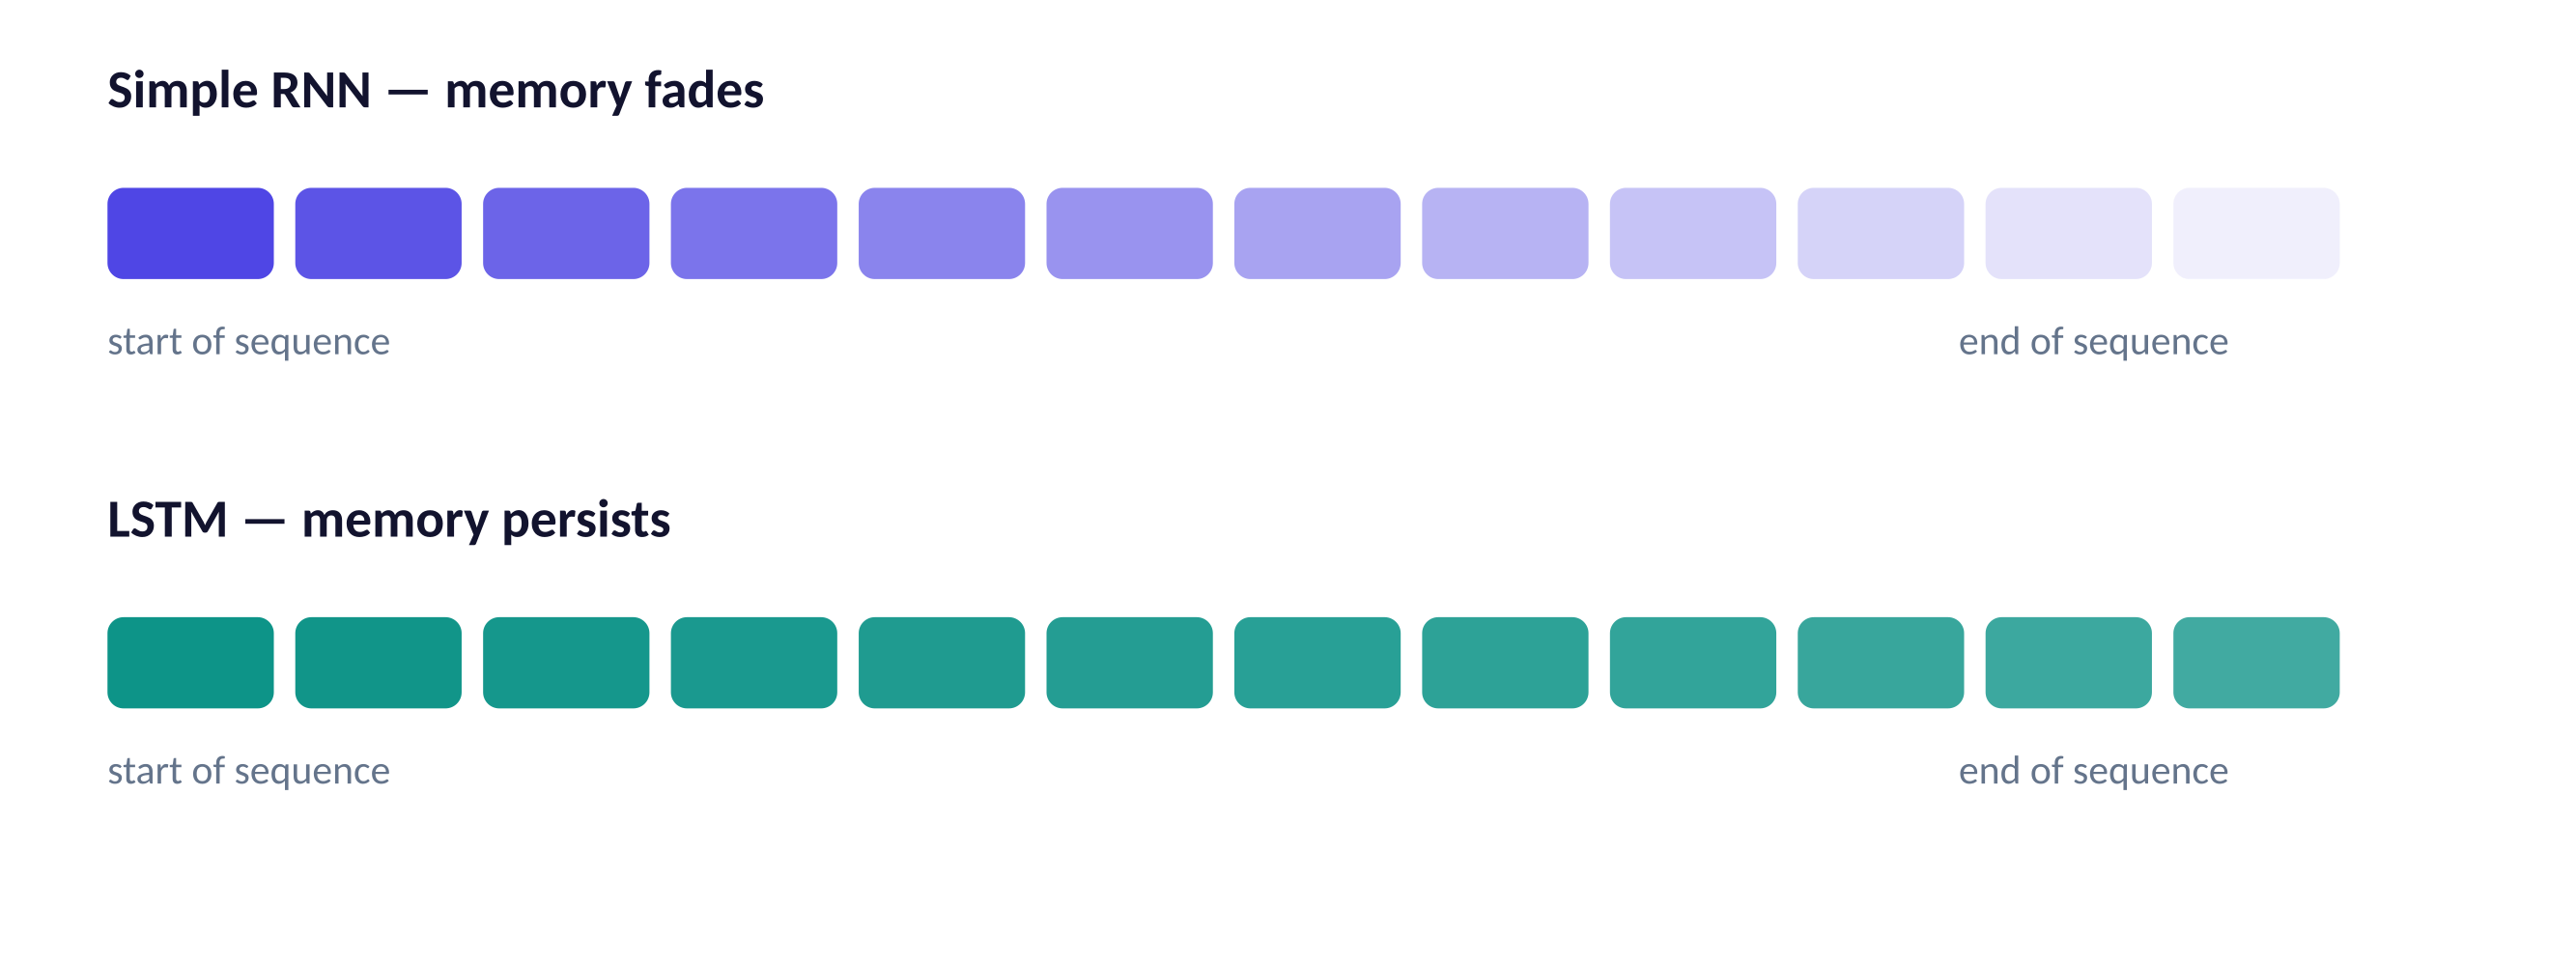<div style="color:#64748B;font-size:13px;font-style:italic;margin-top:6px">SimpleRNN memory fades; the LSTM cell state keeps it alive.</div></div>

### Which model for which job?

| Model | Key idea | Params | Shines when… | Saw it in |
|-------|----------|:------:|--------------|-----------|
| **SimpleRNN** | one shared state | × 1 | dependencies are **short** | Part 1 |
| **LSTM** | cell-state belt + 3 gates | × 4 | **long** structure matters | Part 4 (music) |
| **GRU** | 2 gates, no cell state | × 3 | like LSTM, **lighter / less data** | Part 2 (text) |
| **+ Attention** | content-based focus on any step | + a little | useful info is **far / scattered**, or **interpretability** | Part 3 (pointer task) |

### `return_sequences` — the rule of thumb
- **`False`** → one summary vector for the whole sequence.
- **`True`** → one output per step; required to stack recurrent layers or to apply **attention**.

### *Question 5.1 — wrap-up (answer from your own results)*
1. On short-horizon forecasting (Part 1), which cell gave the best error for the fewest parameters? *Your answer: ...*
2. Why does music (Part 4) need a cell that remembers structure over hundreds of characters? *Your answer: ...*
3. By how much did attention change the accuracy on the pointer task (Part 3)? *Your answer: ...*
4. Give one case where you **must** use `return_sequences=True`. *Your answer: ...*

### When should I add attention?
- The relevant information is **far back** or **spread across** the sequence.
- You need to **explain** the model's decision.
- You can afford the extra compute — **O(m × t)** vs **O(m + t)**.

> 🚀 **Next step:** removing the RNN and keeping *only* attention leads to the **Transformer**.